# Final thesis plots

Clean, publication-quality versions of the main oscillon results, all in one place.
Every panel is rendered inline **and** saved as a PDF (with a PNG mirror) in `GoodFigures/`.

**Conventions (applied to every panel below):**
- One *selection* cell with explicit lists of which parameters to plot.
- One *plot* cell ending in `save_fig(fig, NAME); plt.show()`.

**Index of panels:**
1. Scalar field at $r=0$ vs $t$ and vs shifted $\ln(a)$.
2. Four-panel paper diagnostics (`plot_paper_diagnostics`) for one chosen run.
3. Central density $\rho_c$ vs background density $\bar\rho$ — decoupling from the Hubble flow.
4. Compactness, weak-coupling condition and $g_2$ hyperbolicity (3-stack EFT diagnostics, $\ln(a)\in[2,3.5]$).
5. Density contrast $\delta_c$: with vs without backreaction.
4a. Max compactness heatmap over $(\lambda_{\rm GB},\, g_2)$ at $\beta=0$.
6. GW spectrum benchmark (Antusch-Cefala-Orani 2017, Fig. 2).

Further panels will be added on request, following the same pattern.

## 0 — Imports and output directory

In [1]:
import sys, os, re, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic, plot_paper_diagnostics
from bssn.EFTdiagnostic import get_eft_diagnostic

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
FIG_DIR  = Path(os.getcwd()) / "GoodFigures"
FIG_DIR.mkdir(exist_ok=True)

print(f"DATA_DIR = {DATA_DIR}")
print(f"FIG_DIR  = {FIG_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs
FIG_DIR  = /vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/RunningCode/DATA/GoodFigures


## 1 — Publication style and figure-saving helper

In [2]:
from numpy._core.numeric import False_


plt.rcParams.update({
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "figure.dpi":       120,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.labelsize":   23,
    "axes.titlesize":   16,
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "legend.fontsize":  13,
    "lines.linewidth":  2.5,
    "axes.linewidth":   3,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.minor.width": 0.9,
    "ytick.minor.width": 0.9,
    "xtick.major.size":  5.0,
    "ytick.major.size":  5.0,
    "axes.grid":        False,
    "grid.alpha":       0.3,
})

def save_fig(fig, name):
    """Save fig as both PDF and PNG in GoodFigures/."""
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"  saved {pdf_path.name} and {png_path.name}")

## 2 — Alignment and grid parameters

All runs share the same physical grid and modified-gravity background; alignment shifts each
run's $\ln(a)$ axis so the last crossing of a per-amplitude compactness threshold sits at
`ALIGN_LNA`.

In [3]:
ALIGN_LNA      = 2.0
ALIGN_METHOD   = "last_cross"   # "min_C" or "last_cross"
LNA_MIN_SEARCH = 0.0

C_CROSS_LEVELS = {
    -0.02: 0.02,
    -0.05: 0.04,
    -0.1:  0.06,
    -0.5:  0.125,
}
C_CROSS_DEFAULT = 0.02

LN_A_COMP_MIN = 2.0
LN_A_COMP_MAX = 3.5

scalar_mu = 1
r_max     = 150
min_dr    = 1 / 16
max_dr    = 2
a_mg      = 0.2
b_mg      = 0.4
chi0      = 0.15

## 3 — Alignment helpers

In [4]:
def find_peak_lna(osc, lna_min=0.0):
    """Return ln(a) of the minimum compactness after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

def find_last_crossing_lna(osc, level, lna_min=0.0):
    """Return ln(a) of the last time C crosses `level` (from above) after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    C_sub = C[idx]
    ln_a_sub = ln_a[idx]
    above = C_sub > level
    crossings = np.where(above[:-1] & ~above[1:])[0]
    if len(crossings) == 0:
        return np.nan
    last = crossings[-1]
    frac = (level - C_sub[last+1]) / (C_sub[last] - C_sub[last+1])
    return ln_a_sub[last] * frac + ln_a_sub[last+1] * (1 - frac)

def compactness_in_window(shifted_ln_a, C, lo=LN_A_COMP_MIN, hi=LN_A_COMP_MAX):
    """Mean, min, max, std of C inside [lo, hi] on the *shifted* axis."""
    mask = (shifted_ln_a >= lo) & (shifted_ln_a <= hi)
    if not np.any(mask):
        return np.nan, np.nan, np.nan, np.nan
    c = C[mask]
    return np.mean(c), np.min(c), np.max(c), np.std(c)

def _key_sort(key):
    """Sort key for run-keys that may contain None (e.g. beta=None for linear coupling).

    Maps None -> +inf so linear runs sort after numeric beta values.
    """
    return tuple(float('inf') if v is None else v for v in key)

## 4 — Load all runs at the chosen resolution

Loads every run that matches the loading filters (default: $a_{\rm MG}=b_{\rm MG}=0$, $\Delta r = 1/24$),
computes/loads diagnostics, applies the alignment shift, and also stashes the central scalar field
$\phi(r=0,t)$ so plot 1 doesn't need to reload `solution.npy`.

In [5]:
######## LOADING FILTERS ########
FILTER_A_MG = 0       # None to load all
FILTER_B_MG = 0       # None to load all
FILTER_DR   = 1/24    # None to load all
############################

# Key now includes g2 so quadratic and g2-EFT runs with the same
# (lgb, mu, beta, amp, width) but different g2 don't overwrite each other.
all_runs = {}   # key = (lgb, mu, beta, amp, width, g2)

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0

    m_a = re.search(r"_a([0-9eE.+-]+)_b", tag)
    m_b = re.search(r"_b([0-9eE.+-]+)_amp", tag)
    tag_a = float(m_a.group(1)) if m_a else 0.2
    tag_b = float(m_b.group(1)) if m_b else 0.4

    m_dr = re.search(r"_dr([0-9eE.+-]+)", tag)
    tag_dr = float(m_dr.group(1)) if m_dr else 0.0625

    if FILTER_A_MG is not None and abs(tag_a - FILTER_A_MG) > 1e-10:
        continue
    if FILTER_B_MG is not None and abs(tag_b - FILTER_B_MG) > 1e-10:
        continue
    if FILTER_DR is not None and abs(tag_dr - FILTER_DR) > 1e-4:
        continue

    m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
    if m_beta:
        beta = float(m_beta.group(1))
    elif re.search(r"_quadratic_g2", tag) or tag.endswith("_quadratic"):
        beta = 0.0
    else:
        beta = 250.0

    if "_linear" in tag:
        coupling = "linear"; beta = None
    elif m_beta:
        coupling = f"quadratic_{int(beta)}"
    else:
        coupling = "quadratic"

    # Extract g2: first from directory name, then from metadata, default 0.0
    g2_val = 0.0
    m_g2 = re.search(r"_g2([0-9eE.+-]+)", tag)
    if m_g2:
        g2_val = float(m_g2.group(1))
    else:
        meta_path = os.path.join(run_dir, "metadata.npz")
        if os.path.exists(meta_path):
            try:
                meta = dict(np.load(meta_path, allow_pickle=True))
                if "g2" in meta:
                    g2_val = float(meta["g2"])
            except Exception:
                pass

    # Grid must match the run that wrote solution.npy (notebook r_max/min_dr alone can differ).
    _meta_for_grid = os.path.join(run_dir, "metadata.npz")
    _meta_grid = dict(np.load(_meta_for_grid, allow_pickle=True)) if os.path.exists(_meta_for_grid) else {}
    run_r_max  = float(_meta_grid.get("r_max", r_max))
    run_min_dr = float(_meta_grid.get("min_dr", tag_dr))
    run_max_dr = float(_meta_grid.get("max_dr", max_dr))

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(run_r_max, run_min_dr, run_max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
    else:
        params = (lgb, a_mg, b_mg, chi0, coupling)
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(diag_path, **osc)

    # Stash central scalar field phi(r=0, t)
    N_grid   = len(grid_i.r)
    NUM_VARS = sol.shape[1] // N_grid
    phi_c    = sol[:, 12 * N_grid].copy()

    if ALIGN_METHOD == "last_cross":
        cross_level = C_CROSS_LEVELS.get(amp, C_CROSS_DEFAULT)
        anchor_lna  = find_last_crossing_lna(osc, level=cross_level, lna_min=LNA_MIN_SEARCH)
    else:
        anchor_lna  = find_peak_lna(osc, lna_min=LNA_MIN_SEARCH)
    shift = ALIGN_LNA - anchor_lna if not np.isnan(anchor_lna) else 0.0
    shifted_ln_a = osc["ln_a"] + shift

    C_mean, C_min, C_max, C_std = compactness_in_window(shifted_ln_a, osc["C"])

    key = (lgb, mu, beta, amp, width, g2_val)
    all_runs[key] = dict(
        osc=osc, t=t, phi_c=phi_c, tag=tag,
        lgb=lgb, mu=mu, beta=beta, coupling=coupling, amp=amp, width=width, g2=g2_val,
        run_dir=run_dir, dr=tag_dr,
        run_r_max=run_r_max, run_min_dr=run_min_dr, run_max_dr=run_max_dr,
        shift=shift, shifted_ln_a=shifted_ln_a,
        C_mean=C_mean, C_min=C_min, C_max=C_max, C_std=C_std,
    )

    beta_str = f"beta={int(beta)}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}, g2={g2_val:g}  "
              f"shift={shift:+.3f}  C: no data in window  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}, g2={g2_val:g}  "
              f"shift={shift:+.3f}  C={C_mean:.4e} [{C_min:.4e}, {C_max:.4e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded and aligned")

  lgb=  -1.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.538  C=7.1395e-03 [4.3339e-03, 1.4466e-02]  (1000 steps)
  lgb=  -2.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.536  C=7.0535e-03 [4.2847e-03, 1.3609e-02]  (1000 steps)
  lgb=  -3.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.531  C=6.9746e-03 [4.2228e-03, 1.3554e-02]  (1000 steps)
  lgb=  -4.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.526  C=6.8850e-03 [4.1713e-03, 1.3361e-02]  (1000 steps)
  lgb=  -5.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.524  C=6.8001e-03 [4.1293e-03, 1.3226e-02]  (1000 steps)
  lgb=  -6.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.490  C=6.7319e-03 [4.1234e-03, 1.2932e-02]  (1000 steps)
  lgb=  -7.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.480  C=6.6470e-03 [4.0823e-03, 1.2883e-02]  (1000 steps)
  lgb=  -8.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.475  C=6.5698e-03 [4.0308e-03, 1.2720e-02]  (1000 steps)
  lgb=  

## 5 — Parameter catalogue

Overview of which parameters are available in `all_runs` after filtering.

In [6]:
all_lgb   = sorted(set(k[0] for k in all_runs))
all_mu    = sorted(set(k[1] for k in all_runs))
all_beta  = sorted(set(k[2] for k in all_runs if k[2] is not None))
has_linear = any(k[2] is None for k in all_runs)
all_amp   = sorted(set(k[3] for k in all_runs))
all_width = sorted(set(k[4] for k in all_runs))
all_g2    = sorted(set(k[5] for k in all_runs))
all_couplings = sorted(set(d["coupling"] for d in all_runs.values()))

print(f"runs loaded:      {len(all_runs)}")
print(f"lambda_GB values: {all_lgb}")
print(f"mu values:        {all_mu}")
print(f"beta values:      {all_beta}" + ('  (+ linear runs present)' if has_linear else ''))
print(f"amplitude values: {all_amp}")
print(f"width values:     {all_width}")
print(f"g2 values:        {all_g2}")
print(f"couplings:        {all_couplings}")

print("\nLoaded keys (lgb, mu, beta, amp, width, g2):")
header = (f"  {'lgb':>6s}  {'mu':>5s}  {'beta':>5s}  {'amp':>6s}  {'R':>4s}  {'g2':>6s}  "
          f"{'coupling':<14s}  {'shift':>7s}  {'C_mean':>10s}")
print(header)
print("  " + "-" * (len(header) - 2))
for k in sorted(all_runs.keys(), key=_key_sort):
    d = all_runs[k]
    beta_s = "lin" if k[2] is None else f"{k[2]:g}"
    cmean  = "nan" if np.isnan(d['C_mean']) else f"{d['C_mean']:.3e}"
    print(f"  {k[0]:>6g}  {k[1]:>5g}  {beta_s:>5s}  {k[3]:>6g}  {k[4]:>4g}  {k[5]:>6g}  "
          f"{d['coupling']:<14s}  {d['shift']:>+7.3f}  {cmean:>10s}")

runs loaded:      118
lambda_GB values: [-9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 12.0, 16.0, 20.0]
mu values:        [0.08]
beta values:      [0.0]  (+ linear runs present)
amplitude values: [-1.0, -0.5, -0.1, -0.05, -0.02, -0.0002]
width values:     [3.0]
g2 values:        [-10.0, -5.0, -4.0, -3.0, -2.0, -1.0, -0.5, 0.0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0, 25.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 40.0, 50.0]
couplings:        ['linear', 'quadratic', 'quadratic_0']

Loaded keys (lgb, mu, beta, amp, width, g2):
     lgb     mu   beta     amp     R      g2  coupling          shift      C_mean
  -------------------------------------------------------------------------------
      -9   0.08      0   -0.02     3      20  quadratic_0      +0.474   6.481e-03
      -8   0.08      0   -0.02     3      20  quadratic_0      +0.475   6.570e-03
      -7   0.08      0   -0.02     3      20  quadratic_0 

## 6 — `select_runs` helper

One-liner for the per-panel selection cells. Any argument left as `None` matches all values.

In [7]:
def select_runs(lgb=None, mu=None, beta=None, amp=None, width=None, g2=None, coupling=None):
    """Return list of keys in all_runs whose fields are in the given allowed lists.

    Pass a single value or a list; None = no filter on that dimension.
    Keys are 6-tuples: (lgb, mu, beta, amp, width, g2).
    """
    def _norm(v):
        if v is None: return None
        return v if isinstance(v, (list, tuple, set)) else [v]

    lgb, mu, beta = _norm(lgb), _norm(mu), _norm(beta)
    amp, width, g2 = _norm(amp), _norm(width), _norm(g2)
    coupling = _norm(coupling)

    def _in(x, allowed): return allowed is None or x in allowed

    matches = [
        k for k, d in all_runs.items()
        if _in(k[0], lgb) and _in(k[1], mu) and _in(k[2], beta)
        and _in(k[3], amp) and _in(k[4], width) and _in(k[5], g2)
        and _in(d["coupling"], coupling)
    ]
    return sorted(matches, key=_key_sort)

## Panel 1 — Scalar field at $r=0$

Left subplot: $\phi(r=0)$ vs simulation time $t\ [1/m]$.<br>
Right subplot: $\phi(r=0)$ vs aligned $\ln(a)$.

Edit `PLOT1_*` below to pick which runs go on the figure.

In [9]:
### --- Panel 1 selection (edit me) ---
PLOT1_KEYS = select_runs(
    lgb   = [-5, 0, 5],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2= [0]
)
PLOT1_NAME = "phi_center_evolution"

print(f"{len(PLOT1_KEYS)} run(s) selected for Panel 1:")
for k in PLOT1_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"])

2 run(s) selected for Panel 1:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic
  (5.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0


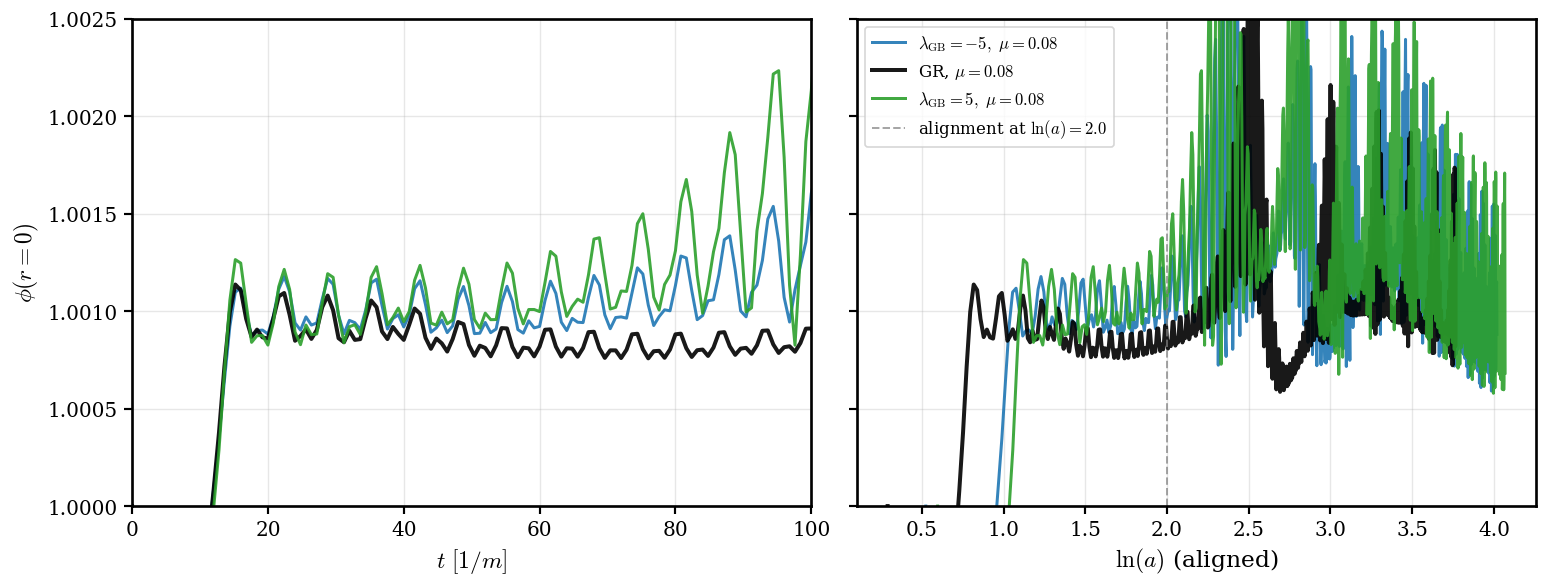

In [26]:
fig, (ax_t, ax_lna) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = plt.cm.tab10

for i, key in enumerate(PLOT1_KEYS):
    data = all_runs[key]
    lgb, mu, beta, amp, width, g2 = key

    if lgb == 0.0:
        label = rf"GR, $\mu={mu}$"
    else:
        beta_s = "" if (beta is None or beta == 0) else rf",\ \beta={int(beta)}"
        label  = rf"$\lambda_{{\rm GB}}={lgb:g},\ \mu={mu}{beta_s}$"

    color = "k" if lgb == 0.0 else cmap(i % 10)
    lw    = 2.4 if lgb == 0.0 else 1.8

    ax_t.plot(data["t"], data["phi_c"], color=color, lw=lw, label=label, alpha=0.9)
    ax_lna.plot(data["shifted_ln_a"], data["phi_c"], color=color, lw=lw, label=label, alpha=0.9)

ax_lna.axvline(ALIGN_LNA, color="grey", ls="--", lw=1.2, alpha=0.7,
               label=rf"alignment at $\ln(a)={ALIGN_LNA}$")

ax_t.set_xlabel(r"$t\ [1/m]$")
ax_t.set_ylabel(r"$\phi(r=0)$")
ax_t.set_ylim(1,1.0025)
ax_t.set_xlim(0,100)
#ax_t.set_title("Central scalar field vs physical time")

ax_lna.set_xlabel(r"$\ln(a)$ (aligned)")
#ax_lna.set_title("Central scalar field vs aligned $\\ln(a)$")

ax_lna.legend(fontsize=10, loc="best", frameon=True)
fig.tight_layout()
#save_fig(fig, PLOT1_NAME)
plt.show()

## Panel 2 — Paper diagnostics for one run

The four standard diagnostic panels from `bssn.oscillondiagnostic.plot_paper_diagnostics`
(density contrast, central density, mass & radius, compactness) plotted on the **shifted**
$\ln(a)$ axis for a single chosen run.

Edit `PLOT2_KEY` and `PLOT2_NAME` below.

In [78]:
### --- Panel 2 selection (edit me) ---
# key format: (lgb, mu, beta, amp, width, g2)
PLOT2_KEY  = (0, 0.08, 0, -0.02, 3.0, 0)
#PLOT2_NAME = "paper_diagnostics_GR_amp-0.02"
PLOT2_NAME = "MassRadiusCompactnessGR"

if PLOT2_KEY not in all_runs:
    print(f"Key {PLOT2_KEY} not found in all_runs.")
    print("Available keys:")
    for k in sorted(all_runs.keys(), key=_key_sort):
        print(" ", k)
else:
    print(f"Selected: {PLOT2_KEY}")
    print(f"  tag      = {all_runs[PLOT2_KEY]['tag']}")
    print(f"  coupling = {all_runs[PLOT2_KEY]['coupling']}")
    print(f"  shift    = {all_runs[PLOT2_KEY]['shift']:+.3f}")

Selected: (0, 0.08, 0, -0.02, 3.0, 0)
  tag      = lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  coupling = quadratic
  shift    = +0.093


<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3279433/854109404.py:68: SyntaxWarning: invalid escape sequence '\l'
  """


  saved MassRadiusCompactnessGR.pdf and MassRadiusCompactnessGR.png


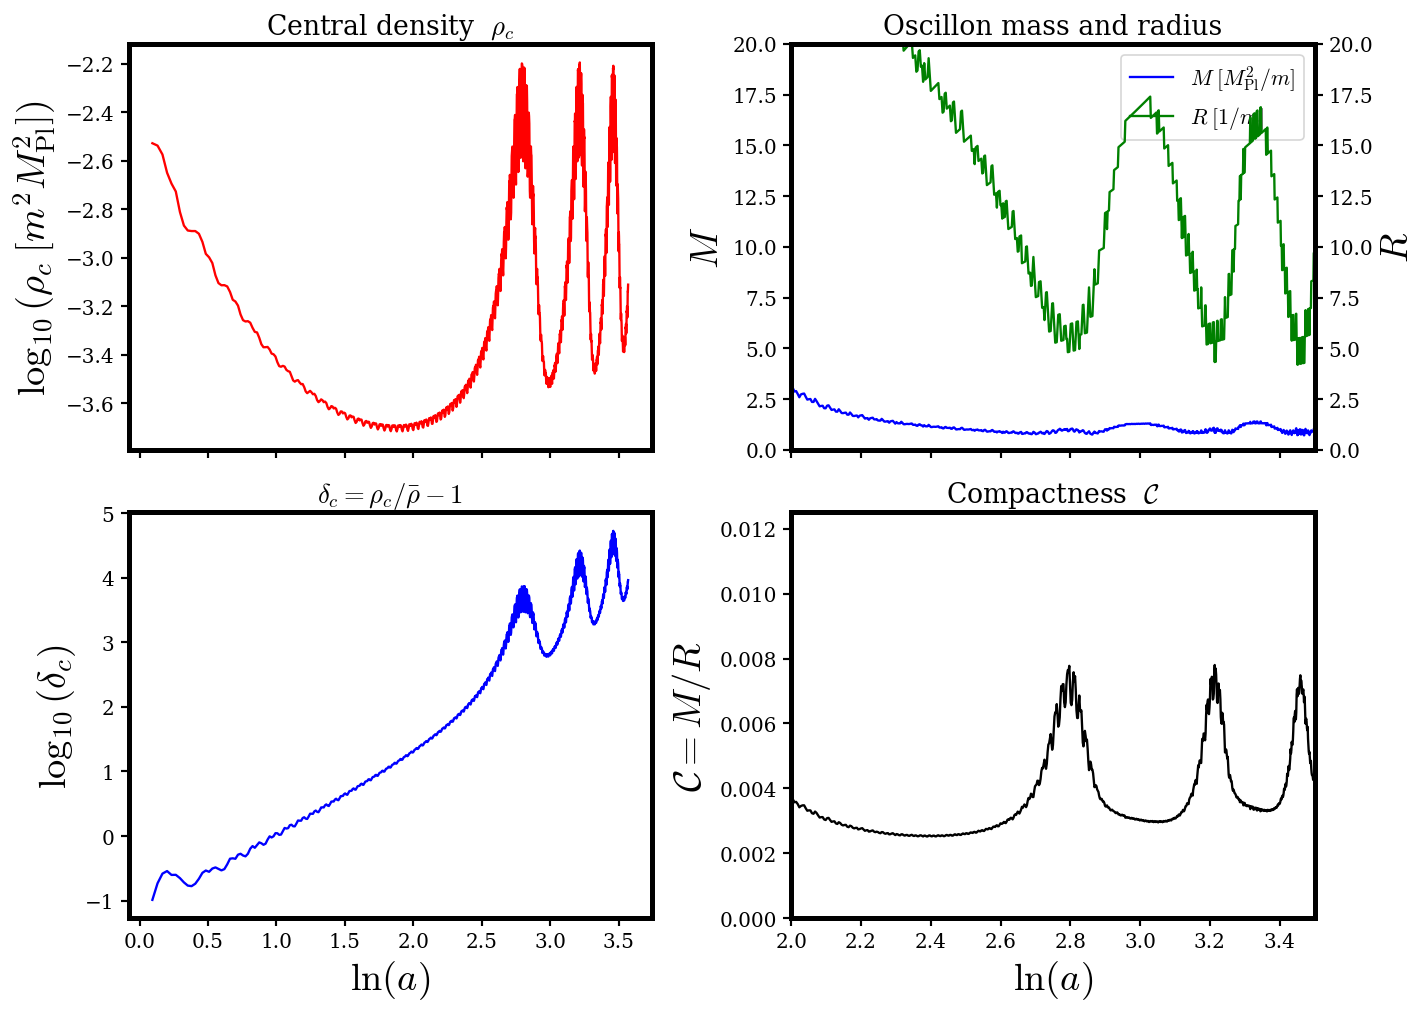

In [79]:
run = all_runs[PLOT2_KEY]
lgb_i, mu_i, beta_i, amp_i, width_i, g2_i = PLOT2_KEY

osc_shifted = {**run["osc"], "ln_a": run["shifted_ln_a"]}

# Custom 2x2 layout (re-arranged from plot_paper_diagnostics):
#   [0,0] log10(rho_c)   [0,1] M and R   (column 1 starts at ln(a)=2)
#   [1,0] log10(delta_c) [1,1] C         (column 1 starts at ln(a)=2)
# Columns share x via sharex='col' so stacked panels have identical x ranges.
x       = osc_shifted["ln_a"]
delta_c = osc_shifted["delta_c"]
rho_c   = osc_shifted["rho_c"]
M_arr   = osc_shifted["M"]
R_arr   = osc_shifted["R"]
C_arr   = osc_shifted["C"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex="col")

# [0,0] central density rho_c
ax = axes[0, 0]
pos_rho = rho_c > 0
y_rho = np.full_like(rho_c, np.nan)
y_rho[pos_rho] = np.log10(rho_c[pos_rho])
ax.plot(x, y_rho, "r-", lw=1.4)
ax.set_ylabel(r"$\log_{10}(\rho_c \; [m^2 M_{\rm Pl}^2])$")
ax.set_title(r"Central density  $\rho_c$")
#ax.grid(True, alpha=0.3)

# [0,1] oscillon mass and radius (starts at ln(a)=2)
ax_mr = axes[0, 1]
ax_mr.plot(x, M_arr, "b-", lw=1.4, label=r"$M \; [M_{\rm Pl}^2/m]$")
ax_mr_r = ax_mr.twinx()
ax_mr_r.plot(x, R_arr, "g-", lw=1.4, label=r"$R \; [1/m]$")
ax_mr.set_ylabel(r"$M$", color="black")
ax_mr_r.set_ylabel(r"$R$", color="black")
ax_mr_r.set_ylim(0,20)
ax_mr.set_ylim(0,20)
ax_mr.set_title("Oscillon mass and radius")
lines1, labels1 = ax_mr.get_legend_handles_labels()
lines2, labels2 = ax_mr_r.get_legend_handles_labels()
ax_mr.legend(lines1 + lines2, labels1 + labels2, fontsize=13, loc="best")
#ax_mr.grid(True, alpha=0.3)

# [1,0] density contrast delta_c
ax = axes[1, 0]
pos = delta_c > 0
y_d = np.full_like(delta_c, np.nan)
y_d[pos] = np.log10(delta_c[pos])
ax.plot(x, y_d, "b-", lw=1.4)
ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\log_{10}(\delta_c)$")
ax.set_title(r"$\delta_c = \rho_c / \bar\rho - 1$")
#ax.grid(True, alpha=0.3)

# [1,1] compactness C (starts at ln(a)=2)
ax = axes[1, 1]
ax.plot(x, C_arr, "k-", lw=1.4)
ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\mathcal{C} = M/R$")
ax.set_title(r"Compactness  $\mathcal{C}$")
ax.set_ylim(0, 1.25e-2)
#ax.grid(True, alpha=0.3)

# x-axis limits per column (column 1 starts at ln(a)=2). sharex='col' propagates.
axes[0, 1].set_xlim(2.0, 3.5)

beta_s = "linear" if beta_i is None else rf"\beta={int(beta_i)}"
"""
fig.suptitle(
    rf"$\lambda_{{\rm GB}}={lgb_i:g},\ \mu={mu_i},\ {beta_s},\ A={amp_i},\ R={width_i}$",
    fontsize=13,)
"""
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, PLOT2_NAME)
plt.show()

  saved MassRadiusCompactnessGR_3stack.pdf and MassRadiusCompactnessGR_3stack.png


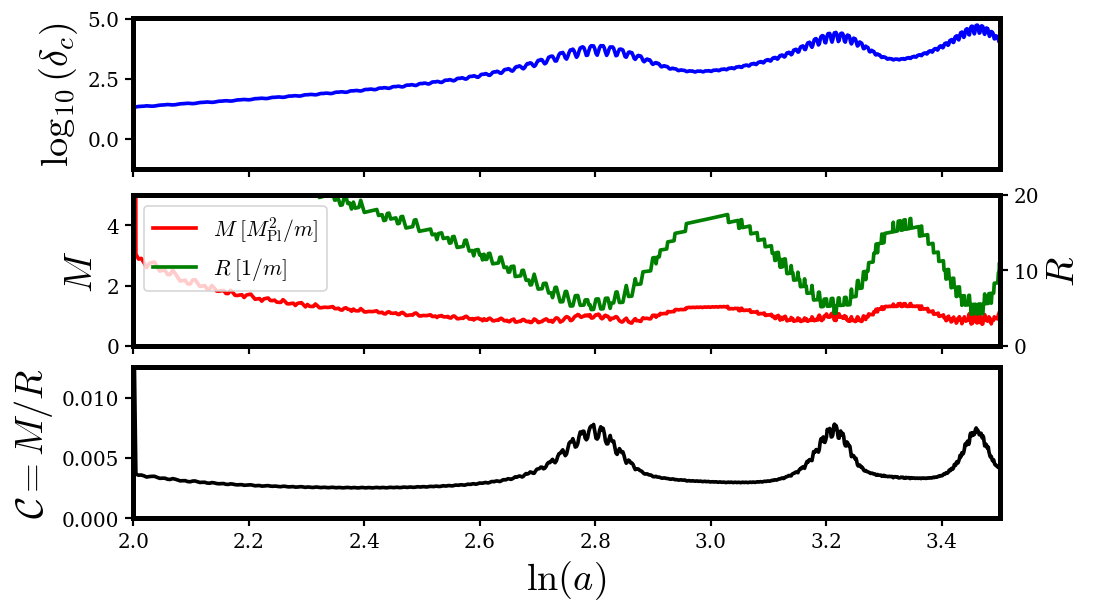

In [116]:
# Panel 2b — same data as Panel 2 (PLOT2_KEY), arranged as 3 stacked panels:
#   top:    log10(delta_c)   vs ln(a)
#   middle: M and R (twinx) vs ln(a)
#   bottom: compactness C    vs ln(a)
# All share x-range [0, 3.5]; vertical grey dotted line at ln(a)=2 marks
# the alignment / "oscillon formed" threshold.
x       = osc_shifted["ln_a"]
delta_c = osc_shifted["delta_c"]
M_arr   = osc_shifted["M"]
R_arr   = osc_shifted["R"]
C_arr   = osc_shifted["C"]

LNA_MIN, LNA_MAX = 2.0, 3.5
LNA_FORM         = 2.0

fig3, (ax_d, ax_mr, ax_c) = plt.subplots(
    3, 1, figsize=(9, 5), sharex=True, constrained_layout=True
)

pos_d = delta_c > 0
y_d   = np.full_like(delta_c, np.nan)
y_d[pos_d] = np.log10(delta_c[pos_d])
ax_d.plot(x, y_d, "b-", lw=2.2)
ax_d.set_ylabel(r"$\log_{10}(\delta_c)$")
#ax_d.set_title(r"$\delta_c = \rho_c / \bar\rho - 1$")


ax_mr.plot(x, M_arr, "r-", lw=2.2, label=r"$M \; [M_{\rm Pl}^2/m]$")
ax_mr_r = ax_mr.twinx()
ax_mr_r.plot(x, R_arr, "g-", lw=2.2, label=r"$R \; [1/m]$")
ax_mr.set_ylabel(r"$M$", color="black")
ax_mr_r.set_ylabel(r"$R$", color="black")
ax_mr.set_ylim(0, 5)
ax_mr_r.set_ylim(0, 20)
#ax_mr.set_title("Oscillon mass and radius")
lines1, labels1 = ax_mr.get_legend_handles_labels()
lines2, labels2 = ax_mr_r.get_legend_handles_labels()
ax_mr.legend(lines1 + lines2, labels1 + labels2,
             fontsize=13, loc="upper left")

ax_c.plot(x, C_arr, "k-", lw=2.2)
ax_c.set_xlabel(r"$\ln(a)$")
ax_c.set_ylabel(r"$\mathcal{C} = M/R$")
#ax_c.set_title(r"Compactness  $\mathcal{C}$")
ax_c.set_ylim(0, 1.25e-2)

for ax in (ax_d, ax_mr, ax_c):
    ax.axvline(LNA_FORM, color="grey", ls=":", lw=1.4, alpha=0.8)
    ax.set_xlim(LNA_MIN, LNA_MAX)

for ax in (ax_mr, ax_c):
    ax.axvspan(LNA_MIN, LNA_FORM, color="lightgrey", alpha=0.45, zorder=0)
    #ax.text(0.5 * (LNA_MIN + LNA_FORM),ax.get_ylim()[0] + 0.92 * (ax.get_ylim()[1] - ax.get_ylim()[0]),"oscillon not formed yet",ha="center", va="top",color="dimgrey", fontsize=13, style="italic")

save_fig(fig3, PLOT2_NAME + "_3stack")
plt.show()

  saved MassRadiusCompactnessGR_2stack.pdf and MassRadiusCompactnessGR_2stack.png


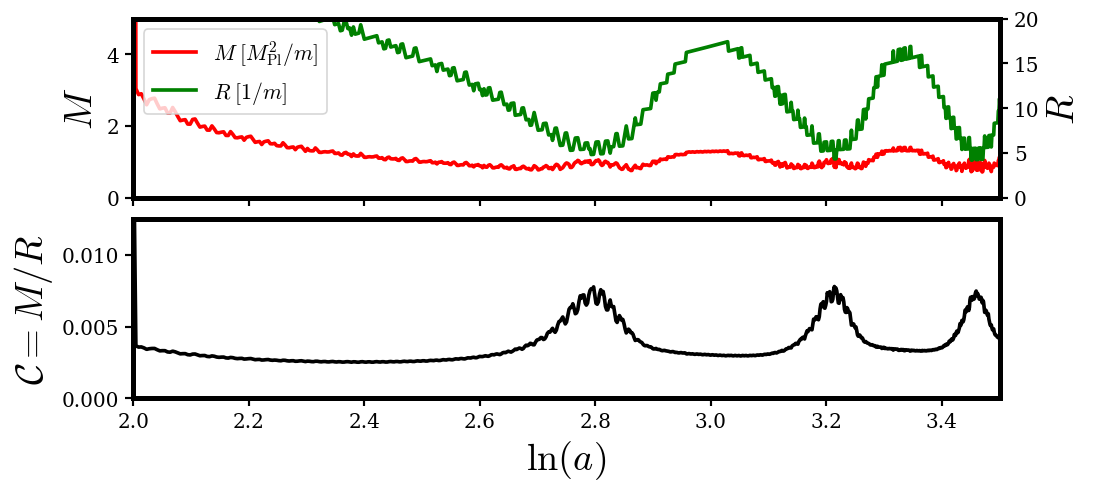

In [117]:
# Panel 2c — same as Panel 2b but with the top log10(delta_c) panel removed.
#   top:    M and R (twinx) vs ln(a)
#   bottom: compactness C    vs ln(a)
x       = osc_shifted["ln_a"]
M_arr   = osc_shifted["M"]
R_arr   = osc_shifted["R"]
C_arr   = osc_shifted["C"]

LNA_MIN, LNA_MAX = 2.0, 3.5
LNA_FORM         = 2.0

fig4, (ax_mr, ax_c) = plt.subplots(
    2, 1, figsize=(9, 4), sharex=True, constrained_layout=True
)

ax_mr.plot(x, M_arr, "r-", lw=2.2, label=r"$M \; [M_{\rm Pl}^2/m]$")
ax_mr_r = ax_mr.twinx()
ax_mr_r.plot(x, R_arr, "g-", lw=2.2, label=r"$R \; [1/m]$")
ax_mr.set_ylabel(r"$M$", color="black")
ax_mr_r.set_ylabel(r"$R$", color="black")
ax_mr.set_ylim(0, 5)
ax_mr_r.set_ylim(0, 20)
lines1, labels1 = ax_mr.get_legend_handles_labels()
lines2, labels2 = ax_mr_r.get_legend_handles_labels()
ax_mr.legend(lines1 + lines2, labels1 + labels2,
             fontsize=13, loc="upper left")

ax_c.plot(x, C_arr, "k-", lw=2.2)
ax_c.set_xlabel(r"$\ln(a)$")
ax_c.set_ylabel(r"$\mathcal{C} = M/R$")
ax_c.set_ylim(0, 1.25e-2)

for ax in (ax_mr, ax_c):
    ax.axvline(LNA_FORM, color="grey", ls=":", lw=1.4, alpha=0.8)
    ax.set_xlim(LNA_MIN, LNA_MAX)
    ax.axvspan(LNA_MIN, LNA_FORM, color="lightgrey", alpha=0.45, zorder=0)

save_fig(fig4, PLOT2_NAME + "_2stack")
plt.show()

## Panel 3 — Central vs background density (decoupling from the Hubble flow)

For each selected run, $\log_{10}\rho_c$ (solid) and $\log_{10}\bar\rho$ (dashed) vs aligned $\ln(a)$.
Where $\rho_c$ stops tracking $\bar\rho$ the configuration has decoupled from the Hubble flow.

In [26]:
### --- Panel 3 selection (edit me) ---
PLOT3_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2 = [0]
)
PLOT3_NAME = "rho_c_vs_rho_bar"

print(f"{len(PLOT3_KEYS)} run(s) selected for Panel 3:")
for k in PLOT3_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"])

1 run(s) selected for Panel 3:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic


  saved rho_c_vs_rho_bar.pdf and rho_c_vs_rho_bar.png


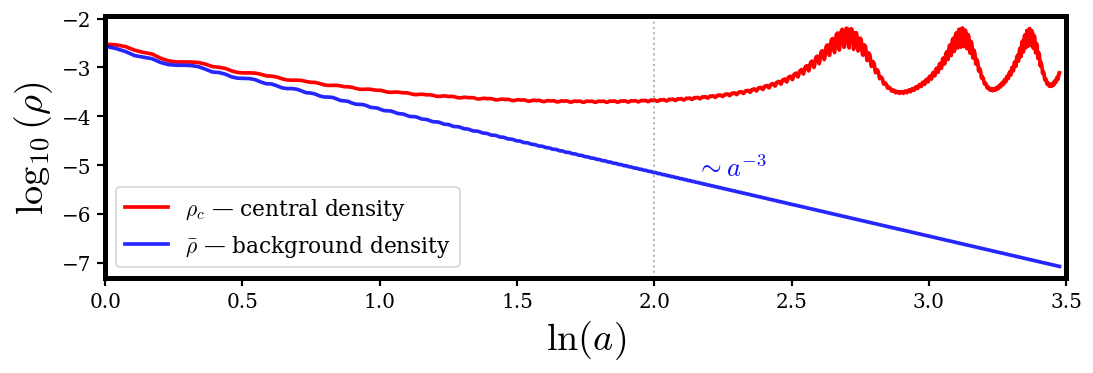

In [27]:
fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)
cmap = plt.cm.tab10
single_run = (len(PLOT3_KEYS) == 1)

for i, key in enumerate(PLOT3_KEYS):
    data = all_runs[key]
    osc  = data["osc"]
    lgb, mu, beta, amp, width, g2 = key

    if "rho_bar" not in osc:
        print(f"  skipping {key}: rho_bar not in diagnostics")
        continue

    #ln_a = data["shifted_ln_a"]
    ln_a = np.asarray(data["osc"]["ln_a"]) #WE USED THE RAW LN(A) FOR GR SINCE THE SHIFTING IS ONLY NEEDED IN MG

    rc   = np.asarray(osc["rho_c"])
    rb   = np.asarray(osc["rho_bar"])

    pos_c = rc >= 0
    pos_b = rb >= 0

    if single_run:
        color_c, color_b = "r", "b"
        lbl_c = r"$\rho_c$ — central density"
        lbl_b = r"$\bar{\rho}$ — background density"
    else:
        color_c = cmap(i % 10)
        color_b = color_c
        beta_s  = "" if (beta is None or beta == 0) else rf",\ \beta={int(beta)}"
        if lgb == 0.0:
            run_lbl = rf"GR, $\mu={mu}$"
        else:
            run_lbl = rf"$\lambda_{{\rm GB}}={lgb:g},\ \mu={mu}{beta_s}$"
        lbl_c = rf"$\rho_c$ (central density) ({run_lbl})"
        lbl_b = rf"$\bar\rho$ (background density) ({run_lbl})"

    ax.plot(ln_a[pos_c], np.log10(rc[pos_c]),color=color_c, lw=2.2, label=lbl_c)
    ax.plot(ln_a[pos_b], np.log10(rb[pos_b]),color=color_b, lw=2.2, ls="-", alpha=0.85, label=lbl_b)

ln_a_ref = np.linspace(1.5, 2.5, 100)
anchor_x = ln_a_ref[0] +2.4
log_rho_anchor = np.interp(anchor_x, ln_a[pos_b], np.log10(rb[pos_b]))
log_rho_ref = log_rho_anchor - 3.0 * (ln_a_ref - anchor_x) / np.log(10)
#ax.plot(ln_a_ref, log_rho_ref,color="black", ls="--", lw=1.5, alpha=0.9)

txt_x = ln_a_ref[len(ln_a_ref) // 2]+0.1
txt_y = -5.5#log_rho_anchor - 3.0 * (txt_x - anchor_x) / np.log(10)
ax.annotate(r"$\sim a^{-3}$",
            xy=(txt_x, txt_y),
            xytext=(8, 8), textcoords="offset points",
            color="blue", fontsize=16, alpha=0.95)

ax.axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)

ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\log_{10}(\rho)$")
ax.set_xlim(0,3.5)
#ax.set_title(r"Central density $\rho_c$ vs background $\bar{\rho}$")
ax.legend(fontsize=13, loc="best", frameon=True)
save_fig(fig, PLOT3_NAME)
plt.show()

---
## Further panels

Future panels follow the same two-cell pattern:

- **Selection cell** — set parameter lists and a `*_NAME` string used for the PDF filename.
- **Plot cell** — build the figure, then `save_fig(fig, NAME); plt.show()` so it is shown
  inline and saved to `GoodFigures/NAME.pdf` (with a `.png` mirror).

## Panel 5 — Density contrast $\delta_c$: with vs without backreaction

Compares $\log_{10}(\delta_c)$ vs $\ln(a)$ for the **same** physical setup
( $\mu = 0.08$, $\lambda_{\rm GB} = 0$, $g_2 = 0$, $a_{\rm mg}=b_{\rm mg}=0$,
$A=-0.02$, $R=3$, $\mathrm{d}r=1/24$, $T=800$ ) with two different gravity settings:

- **With backreaction**: `eight_pi_G = 1` in `bssn/tensoralgebra.py` (the existing run).
- **Without backreaction**: `eight_pi_G = 0` (the run currently submitted to wICE).
  This effectively evolves the scalar on a fixed FLRW background, mirroring what a
  linear / fixed-background code computes.

The black dashed line shows the matter-domination linear growth $\delta_c \propto a$
(slope $\log_{10}(e) \approx 0.4343$ in this plane), anchored to the no-BR curve's
first positive value.

Both runs are loaded directly from disk (not from `all_runs`), because the
notebook's loader keys on `(\lambda_{GB}, \mu, \beta, A, R, g_2)` and both runs collide
to the same key — only their `coupling` string differs (`"quadratic"` vs
`"quadratic_0_noBR"`).

with backreaction:
  dir          : /data/leuven/384/vsc38419/oscillon_runs/lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  solution.npy : True
  diagnostics  : True
no backreaction:
  dir          : /data/leuven/384/vsc38419/oscillon_runs/lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_noBR_g20
  solution.npy : True
  diagnostics  : True
  saved delta_c_with_vs_no_backreaction_mu0.08_amp-0.02.pdf and delta_c_with_vs_no_backreaction_mu0.08_amp-0.02.png


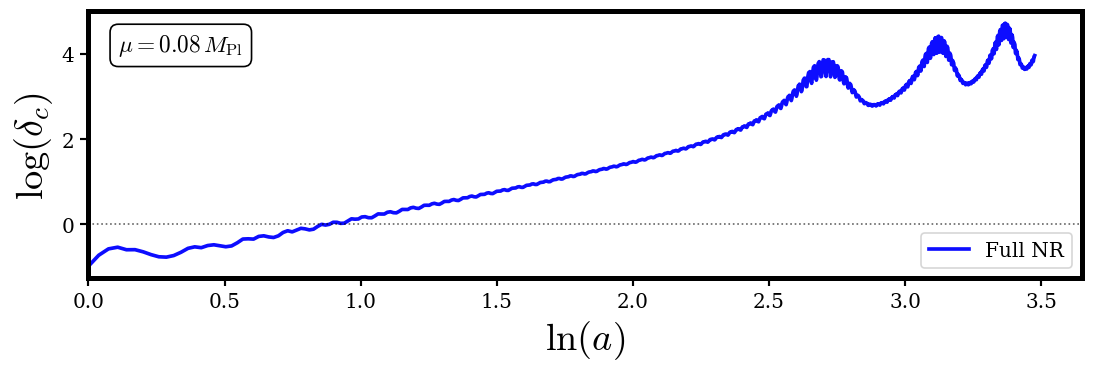

In [28]:
# ── Panel 5 selection (edit me if you change run parameters) ──────────────
# Pick ONE pair below by commenting/uncommenting.  Both pairs share the same
# physical parameters (mu=0.08, lgb=0, g2=0, a=b=0, R=3, dr=1/24, T=800);
# they only differ in the initial perturbation amplitude A.

# --- A = -0.02 ---
NOBR_TAG    = "lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_noBR_g20"
WITHBR_TAG  = "lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20"
P5_NAME     = "delta_c_with_vs_no_backreaction_mu0.08_amp-0.02"

# --- A = -0.0002 ---
#NOBR_TAG    = "lgb0_mu0.08_a0_b0_amp-0.0002_R3_dr0.0416667_quadratic_0_noBR_g20"
#WITHBR_TAG  = "lgb0_mu0.08_a0_b0_amp-0.0002_R3_dr0.0416667_quadratic_g20"
#P5_NAME     = "delta_c_with_vs_no_backreaction_mu0.08_amp-0.0002"

# Physical parameters (must match the runs above)
P5_LGB, P5_MU, P5_G2 = 0.0, 0.08, 0.0
P5_COUPLING_NOBR    = "quadratic_0_noBR"
P5_COUPLING_WITHBR  = "quadratic"


def _p5_load_or_compute_diag(run_dir, mu, coupling, lgb, g2):
    """Load diagnostics.npz from `run_dir`; compute if missing but solution.npy exists.
    Returns None if the simulation hasn't produced solution.npy yet.
    """
    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        return dict(np.load(diag_path, allow_pickle=True))

    sol_path = os.path.join(run_dir, "solution.npy")
    t_path   = os.path.join(run_dir, "t.npy")
    if not (os.path.exists(sol_path) and os.path.exists(t_path)):
        return None

    meta_path = os.path.join(run_dir, "metadata.npz")
    if os.path.exists(meta_path):
        meta = dict(np.load(meta_path, allow_pickle=True))
        run_r_max  = float(meta.get("r_max",  r_max))
        run_min_dr = float(meta.get("min_dr", 1/24))
        run_max_dr = float(meta.get("max_dr", max_dr))
    else:
        run_r_max, run_min_dr, run_max_dr = r_max, 1/24, max_dr

    sol_i   = np.load(sol_path)
    t_i     = np.load(t_path)
    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(run_r_max, run_min_dr, run_max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)
    params_i  = (lgb, a_mg, b_mg, chi0, coupling, g2)
    osc_d = get_oscillon_diagnostic(
        sol_i, t_i, grid_i, bg_i,
        ScalarMatter(scalar_mu, mu),
        params_i, surface_threshold=0.05, r_max_diag=100.0,
    )
    np.savez(diag_path, **osc_d)
    return osc_d


nobr_dir   = os.path.join(DATA_DIR, NOBR_TAG)
withbr_dir = os.path.join(DATA_DIR, WITHBR_TAG)

print("with backreaction:")
print(f"  dir          : {withbr_dir}")
print(f"  solution.npy : {os.path.exists(os.path.join(withbr_dir, 'solution.npy'))}")
print(f"  diagnostics  : {os.path.exists(os.path.join(withbr_dir, 'diagnostics.npz'))}")
print("no backreaction:")
print(f"  dir          : {nobr_dir}")
print(f"  solution.npy : {os.path.exists(os.path.join(nobr_dir,  'solution.npy'))}")
print(f"  diagnostics  : {os.path.exists(os.path.join(nobr_dir,  'diagnostics.npz'))}")

osc_with = _p5_load_or_compute_diag(withbr_dir, mu=P5_MU, coupling=P5_COUPLING_WITHBR,
                                     lgb=P5_LGB, g2=P5_G2)
osc_no   = _p5_load_or_compute_diag(nobr_dir,   mu=P5_MU, coupling=P5_COUPLING_NOBR,
                                     lgb=P5_LGB, g2=P5_G2)

if osc_with is None:
    print("\n[warn] with-backreaction run has no solution.npy yet — plot will be empty for that curve.")
if osc_no is None:
    print("\n[info] no-backreaction run has not produced solution.npy yet "
          "(simulation still in progress). Only the with-backreaction curve will be drawn.")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)

def _plot_logdelta(ax, osc, color, ls, lw, label, x_override=None):
    if osc is None:
        return
    ln_a = x_override if x_override is not None else np.asarray(osc["ln_a"])
    dc   = np.asarray(osc["delta_c"])
    pos = (dc > 0) & np.isfinite(dc)
    if not np.any(pos):
        return
    y = np.full_like(dc, np.nan, dtype=float)
    y[pos] = np.log10(dc[pos])
    ax.plot(ln_a, y, color=color, ls=ls, lw=lw, label=label, alpha=0.95)

# ── X-axis mode ───────────────────────────────────────────────────────────
# Toggle: "t" = coordinate time,  "ln_a" = with-BR ln(a) for both curves
#P5_XAXIS = "t"
P5_XAXIS = "ln_a"

if P5_XAXIS == "t":
    x_with = np.asarray(osc_with["t"]) if osc_with is not None else None
    x_no   = np.asarray(osc_no["t"])   if osc_no   is not None else None
    p5_xlabel = r"$t \; [1/m]$"
else:
    x_with = np.asarray(osc_with["ln_a"]) if osc_with is not None else None
    x_no   = x_with
    p5_xlabel = r"$\ln(a)$"

_plot_logdelta(ax, osc_with, color="blue", ls="-",  lw=2.2, label="Full NR",x_override=x_with)
#_plot_logdelta(ax, osc_no,   color="red",  ls="-", lw=2.2, label="no backreaction",x_override=x_no)

ax.axhline(0.0, color="k", ls=":", lw=1.0, alpha=0.6)

ax.set_xlabel(p5_xlabel)
ax.set_ylabel(r"$\log(\delta_c)$")
ax.set_xlim(left=0.0)
ax.legend(loc="lower right", frameon=True, fontsize=12)

ax.text(0.03, 0.92, rf"$\mu = {P5_MU:g}\,M_{{\rm Pl}}$",
        transform=ax.transAxes, fontsize=14, ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", lw=1.0))

save_fig(fig, P5_NAME)
plt.show()

## Panel 6 — Density-contrast profile $\delta(r)$

Snapshot plot of the spatial density-contrast profile

$$\delta(r,\, t) \;=\; \frac{\rho(r,\, t)}{\bar\rho(t)} \;-\; 1$$

against the radial coordinate $r$, evaluated at a set of aligned $\ln(a)$
snapshots.  This is the radial generalisation of the central density
contrast $\delta_c = \rho_c / \bar\rho - 1$ used in the earlier panels;
note that $\delta(r=0,\, t) \equiv \delta_c(t)$, so each curve passes
through $\delta_c$ on the y-axis at $r=0$.

Two display modes are available:

* `PLOT6_USE_OSC_RADIUS = False` — x-axis is the **physical radial coordinate**
  $r\,[1/m]$, capped at `PLOT6_R_MAX`.
* `PLOT6_USE_OSC_RADIUS = True`  — x-axis is **rescaled by the time-dependent
  oscillon radius** $R_{\rm osc}(t)$, i.e. $r/R_{\rm osc}(t)$, capped at
  `PLOT6_X_NORM_MAX`.  In this mode the oscillon "edge" sits at
  $r/R_{\rm osc}=1$ (marked with a thin grey dotted vertical line) and
  self-similar profiles collapse onto each other.

Edit `PLOT6_KEY`, `PLOT6_SNAPS`, `PLOT6_USE_OSC_RADIUS`, `PLOT6_R_MAX`,
`PLOT6_X_NORM_MAX` and `PLOT6_NAME` below.


In [44]:
PLOT6_KEY    = (0, 0.08, 0, -0.02, 3.0, 0)
#PLOT6_SNAPS  = [2.0, 2.25, 2.5, 3]
PLOT6_SNAPS  = [2.0,2.1,2.15,2.2, 2.25,2.3,2.35,2.4,2.45, 2.5,2.55,2.6,2.65]

PLOT6_USE_OSC_RADIUS = False
PLOT6_R_MAX          = 3
PLOT6_X_NORM_MAX     = 5.0

PLOT6_NAME   = "delta_profile_lgb0_mu0.08_amp-0.02"

if PLOT6_KEY not in all_runs:
    print(f"Key {PLOT6_KEY} not found in all_runs.")
    print("Available keys:")
    for k in sorted(all_runs.keys()):
        print(f"  {k}  coupling={all_runs[k]['coupling']}")
else:
    print(f"Selected: {PLOT6_KEY}")
    print(f"  tag      = {all_runs[PLOT6_KEY]['tag']}")
    print(f"  coupling = {all_runs[PLOT6_KEY]['coupling']}")
    print(f"  shift    = {all_runs[PLOT6_KEY]['shift']:+.3f}")


Selected: (0, 0.08, 0, -0.02, 3.0, 0)
  tag      = lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  coupling = quadratic
  shift    = +0.093


  saved delta_profile_lgb0_mu0.08_amp-0.02.pdf and delta_profile_lgb0_mu0.08_amp-0.02.png


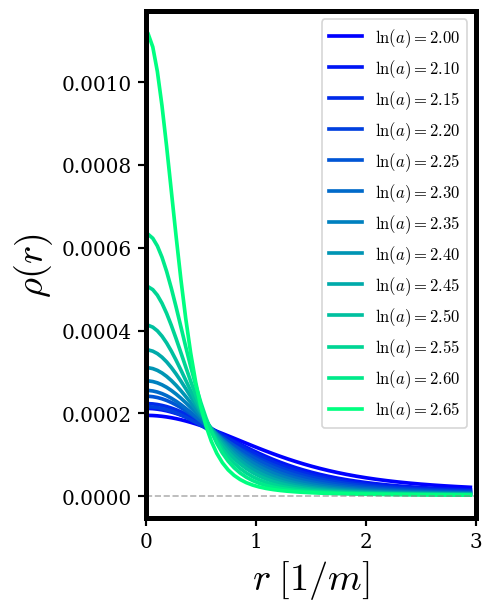

In [53]:
run    = all_runs[PLOT6_KEY]
osc    = run["osc"]
r_grid = np.asarray(osc["r"])
s_ln_a = np.asarray(run["shifted_ln_a"])

if "delta_rho" in osc:
    #delta_rho = np.asarray(osc["delta_rho"])
    delta_rho = np.asarray(osc["rho"])
else:
    rho     = np.asarray(osc["rho"])
    rho_bar = np.asarray(osc["rho_bar"])
    delta_rho = rho / np.maximum(rho_bar[:, None], 1e-30) - 1.0

R_osc_t = np.asarray(osc["R"])

snap_indices = [int(np.argmin(np.abs(s_ln_a - v))) for v in PLOT6_SNAPS]

fig, ax = plt.subplots(figsize=(4, 5), constrained_layout=True)
cmap = plt.cm.winter
n    = len(snap_indices)

for j, idx in enumerate(snap_indices):
    color   = cmap(j / max(n - 1, 1))
    lna_val = s_ln_a[idx]
    delta_r = delta_rho[idx]

    if PLOT6_USE_OSC_RADIUS:
        R_osc = R_osc_t[idx]
        if R_osc <= 0:
            print(f"Skipping ln(a)={lna_val:.2f}: R_osc = {R_osc:.3g} (no oscillon yet)")
            continue
        x      = r_grid / R_osc
        x_mask = (r_grid >= 0) & (x <= PLOT6_X_NORM_MAX)
        lbl    = rf"$\ln(a) = {lna_val:.2f},\ R_{{\rm osc}} = {R_osc:.2f}$"
    else:
        x      = r_grid
        x_mask = (r_grid >= 0) & (r_grid <= PLOT6_R_MAX)
        lbl    = rf"$\ln(a) = {lna_val:.2f}$"

    ax.plot(x[x_mask], delta_r[x_mask],color=color, lw=2.2, label=lbl)

ax.axhline(0.0, color="grey", ls="--", lw=1.0, alpha=0.6)

if PLOT6_USE_OSC_RADIUS:
    ax.axvline(1.0, color="grey", ls=":", lw=1.2, alpha=0.7)
    ax.set_xlabel(r"$r / R_{\rm osc}(t)$")
    ax.set_xlim(0, PLOT6_X_NORM_MAX)
    save_suffix = "_vs_rOverR"
else:
    ax.set_xlabel(r"$r \; [1/m]$")
    ax.set_xlim(0, PLOT6_R_MAX)
    save_suffix = ""

#ax.set_ylabel(r"$\delta_c(r)$")
ax.set_ylabel(r"$\rho(r)$")
ax.legend(fontsize=10, loc="best", frameon=True)
save_fig(fig, PLOT6_NAME + save_suffix)
plt.show()


## Panel 7 — 2D density-contrast slice $\delta(x, y)$

Renders the spherically-symmetric radial profile $\delta(r,\, t)$ as a 2D
heatmap on the $(x, y)$ plane by rotating it around the origin:

$$\delta(x, y) \;=\; \delta\!\bigl(\sqrt{x^2 + y^2},\, t\bigr).$$

This visualisation gives a "2D-slice" feel for a strictly 1D run; because
the underlying data is radial, the resulting image is necessarily
*concentric* (a single bullseye rather than several oscillons floating
around like in a true 2D/3D simulation).

The snapshot is picked by setting `PLOT7_LNA` to a value of (aligned)
$\ln(a)$ — the plot cell snaps to the closest available simulation
snapshot.

Edit `PLOT7_KEY`, `PLOT7_LNA`, `PLOT7_X_MAX`, `PLOT7_NPIX`, `PLOT7_CMAP`,
`PLOT7_VMIN`, `PLOT7_VMAX` and `PLOT7_NAME` below.

In [70]:
PLOT7_KEY   = (0, 0.08, 0, -0.02, 3.0, 0)
PLOT7_LNA   = 2.5
PLOT7_X_MAX = 3.0
PLOT7_NPIX  = 400
PLOT7_CMAP  = "jet"
PLOT7_VMIN  = None
PLOT7_VMAX  = None
PLOT7_NAME  = "delta_2D_lgb0_mu0.08_amp-0.02"

if PLOT7_KEY not in all_runs:
    print(f"Key {PLOT7_KEY} not found in all_runs.")
    print("Available keys:")
    for k in sorted(all_runs.keys()):
        print(f"  {k}  coupling={all_runs[k]['coupling']}")
else:
    s_ln_a_tmp = np.asarray(all_runs[PLOT7_KEY]["shifted_ln_a"])
    idx_tmp    = int(np.argmin(np.abs(s_ln_a_tmp - PLOT7_LNA)))
    print(f"Selected: {PLOT7_KEY}")
    print(f"  tag                    = {all_runs[PLOT7_KEY]['tag']}")
    print(f"  shift                  = {all_runs[PLOT7_KEY]['shift']:+.3f}")
    print(f"  requested ln(a)        = {PLOT7_LNA}")
    print(f"  closest snapshot ln(a) = {s_ln_a_tmp[idx_tmp]:.3f}  (idx={idx_tmp})")

Selected: (0, 0.08, 0, -0.02, 3.0, 0)
  tag                    = lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  shift                  = +0.093
  requested ln(a)        = 2.5
  closest snapshot ln(a) = 2.501  (idx=311)


  saved delta_2D_lgb0_mu0.08_amp-0.02_lna2p50.pdf and delta_2D_lgb0_mu0.08_amp-0.02_lna2p50.png


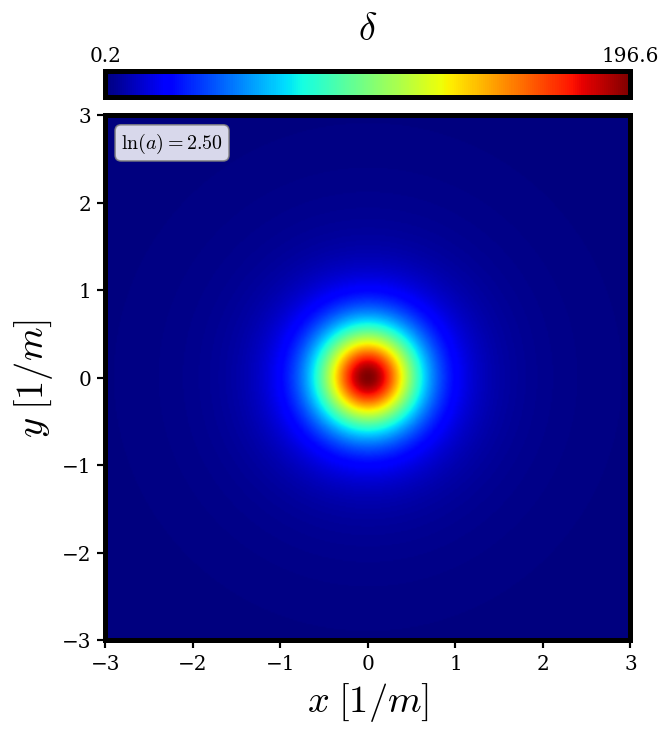

In [74]:
run    = all_runs[PLOT7_KEY]
osc    = run["osc"]
r_grid = np.asarray(osc["r"])
s_ln_a = np.asarray(run["shifted_ln_a"])

if "delta_rho" in osc:
    delta_rho = np.asarray(osc["delta_rho"])
    #delta_rho = np.asarray(osc["rho"])
else:
    rho     = np.asarray(osc["rho"])
    rho_bar = np.asarray(osc["rho_bar"])
    delta_rho = rho / np.maximum(rho_bar[:, None], 1e-30) - 1.0

idx     = int(np.argmin(np.abs(s_ln_a - PLOT7_LNA)))
lna_val = s_ln_a[idx]
prof    = delta_rho[idx]

order    = np.argsort(r_grid)
r_sorted = r_grid[order]
p_sorted = prof[order]

n  = PLOT7_NPIX
xs = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
ys = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
X, Y = np.meshgrid(xs, ys)
R    = np.sqrt(X**2 + Y**2)

delta_2d = np.interp(R, r_sorted, p_sorted,
                     left=p_sorted[0], right=0.0)

vmin = float(np.nanmin(delta_2d)) if PLOT7_VMIN is None else PLOT7_VMIN
vmax = float(np.nanmax(delta_2d)) if PLOT7_VMAX is None else PLOT7_VMAX

fig, ax = plt.subplots(figsize=(5.5, 6.0), constrained_layout=True)
im = ax.imshow(
    delta_2d,
    extent=[-PLOT7_X_MAX, PLOT7_X_MAX, -PLOT7_X_MAX, PLOT7_X_MAX],
    origin="lower",
    cmap=PLOT7_CMAP,
    vmin=vmin, vmax=vmax,
    aspect="equal",
    interpolation="bilinear",
)

ax.set_xlabel(r"$x \; [1/m]$")
ax.set_ylabel(r"$y \; [1/m]$")

cbar = fig.colorbar(im, ax=ax, orientation="horizontal", location="top",
                    fraction=0.05, pad=0.02)
cbar.set_label(r"$\delta$")
cbar.set_ticks([vmin, vmax])
cbar.ax.tick_params(direction="in")

ax.text(0.03, 0.97, rf"$\ln(a) = {lna_val:.2f}$",
        transform=ax.transAxes, va="top", ha="left", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", alpha=0.85, edgecolor="grey"))

save_fig(fig, PLOT7_NAME + f"_lna{lna_val:.2f}".replace(".", "p"))
plt.show()

  saved panel8_radial_and_2DD_lna2p50.pdf and panel8_radial_and_2DD_lna2p50.png


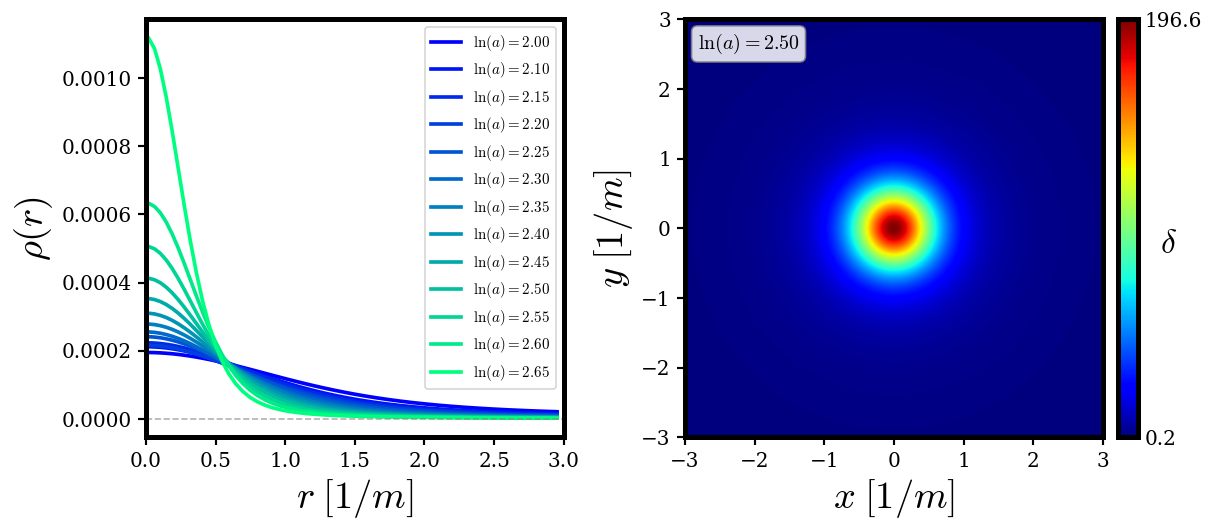

In [115]:
# Panel 8 — combined view: radial profiles (left) + rotated 2D slice (right).
# Uses the existing PLOT6_* and PLOT7_* selection variables, so re-run the
# Panel 6 and Panel 7 selection cells first if you change the parameters.

# ── Left-panel data: radial rho(r) profiles at PLOT6_SNAPS ─────────────────
run6    = all_runs[PLOT6_KEY]
osc6    = run6["osc"]
r6      = np.asarray(osc6["r"])
ln_a6   = np.asarray(run6["shifted_ln_a"])
field6  = np.asarray(osc6["rho"])
field6_label = r"$\rho(r)$"
R_osc_t6     = np.asarray(osc6["R"])
snap_idx6    = [int(np.argmin(np.abs(ln_a6 - v))) for v in PLOT6_SNAPS]

# ── Right-panel data: rotated 2D slice of delta(x, y) at PLOT7_LNA ─────────
run7   = all_runs[PLOT7_KEY]
osc7   = run7["osc"]
r7     = np.asarray(osc7["r"])
ln_a7  = np.asarray(run7["shifted_ln_a"])

if "delta_rho" in osc7:
    field7 = np.asarray(osc7["delta_rho"])
else:
    rho     = np.asarray(osc7["rho"])
    rho_bar = np.asarray(osc7["rho_bar"])
    field7  = rho / np.maximum(rho_bar[:, None], 1e-30) - 1.0

idx7     = int(np.argmin(np.abs(ln_a7 - PLOT7_LNA)))
lna_val7 = ln_a7[idx7]
prof7    = field7[idx7]

order7    = np.argsort(r7)
r_sorted7 = r7[order7]
p_sorted7 = prof7[order7]

n  = PLOT7_NPIX
xs = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
ys = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
X, Y = np.meshgrid(xs, ys)
R    = np.sqrt(X**2 + Y**2)

delta_2d = np.interp(R, r_sorted7, p_sorted7,
                     left=p_sorted7[0], right=0.0)
vmin = float(np.nanmin(delta_2d)) if PLOT7_VMIN is None else PLOT7_VMIN
vmax = float(np.nanmax(delta_2d)) if PLOT7_VMAX is None else PLOT7_VMAX

# ── Side-by-side figure ───────────────────────────────────────────────────
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(10, 5), constrained_layout=True,
)
axL.set_box_aspect(1)

cmap6 = plt.cm.winter
m     = len(snap_idx6)
for j, idx in enumerate(snap_idx6):
    color = cmap6(j / max(m - 1, 1))
    lna_v = ln_a6[idx]
    yprof = field6[idx]

    if PLOT6_USE_OSC_RADIUS:
        R_osc = R_osc_t6[idx]
        if R_osc <= 0:
            print(f"Skipping ln(a)={lna_v:.2f}: R_osc = {R_osc:.3g} (no oscillon yet)")
            continue
        x_axis = r6 / R_osc
        x_mask = (r6 >= 0) & (x_axis <= PLOT6_X_NORM_MAX)
        lbl    = rf"$\ln(a) = {lna_v:.2f},\ R_{{\rm osc}} = {R_osc:.2f}$"
    else:
        x_axis = r6
        x_mask = (r6 >= 0) & (r6 <= PLOT6_R_MAX)
        lbl    = rf"$\ln(a) = {lna_v:.2f}$"

    axL.plot(x_axis[x_mask], yprof[x_mask], color=color, lw=2.2, label=lbl)

axL.axhline(0.0, color="grey", ls="--", lw=1.0, alpha=0.6)
if PLOT6_USE_OSC_RADIUS:
    axL.axvline(1.0, color="grey", ls=":", lw=1.2, alpha=0.7)
    axL.set_xlabel(r"$r / R_{\rm osc}(t)$")
    axL.set_xlim(0, PLOT6_X_NORM_MAX)
else:
    axL.set_xlabel(r"$r \; [1/m]$")
    axL.set_xlim(0, PLOT6_R_MAX)
axL.set_ylabel(field6_label)
axL.legend(fontsize=9, loc="best", frameon=True)

im = axR.imshow(
    delta_2d,
    extent=[-PLOT7_X_MAX, PLOT7_X_MAX, -PLOT7_X_MAX, PLOT7_X_MAX],
    origin="lower",
    cmap=PLOT7_CMAP,
    vmin=vmin, vmax=vmax,
    aspect="equal",
    interpolation="bilinear",
)
axR.set_xlabel(r"$x \; [1/m]$")
axR.set_ylabel(r"$y \; [1/m]$")

cbar = fig.colorbar(im, ax=axR, orientation="vertical", location="right",fraction=0.05, pad=0.02)
cbar.set_label(r"$\delta$", rotation=0, labelpad=-20, fontsize=20)
cbar.set_ticks([vmin, vmax])
cbar.ax.tick_params(direction="in")

axR.text(0.03, 0.97, rf"$\ln(a) = {lna_val7:.2f}$",
         transform=axR.transAxes, va="top", ha="left", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white", alpha=0.85, edgecolor="grey"))

save_fig(fig, "panel8_radial_and_2DD" + f"_lna{lna_val7:.2f}".replace(".", "p"))
plt.show()

## Panel 4b — Compactness $\mathcal{C}$ vs $g_2$ (peak statistics, last 0.2 e-folds)

For each $(\lambda_{\rm GB}, g_2)$ run, the local maxima of $\mathcal{C}(t)$ are identified
inside the **last $\Delta\ln a = 0.2$ e-folds** of the aligned `shifted_ln_a` axis (the window
where the configuration has stabilised). The plotted point and error bar are

$$\langle\mathcal{C}\rangle = \overline{\mathcal{C}_{\rm peak}}, \qquad
  \sigma_{\mathcal{C}} = \mathrm{std}\bigl(\mathcal{C}_{\rm peak}\bigr).$$

This is the "peak-statistics" estimator: instead of mean $\pm$ std over the whole window
(which would mostly measure the breathing amplitude, not how well-determined the answer is),
the bar now reflects **cycle-to-cycle variation of the maximum compactness from one breath
to the next**. A virialised oscillon has nearly identical successive peaks and gives a small
bar; a still-settling or fragmenting one gives a large bar. Runs with fewer than two
interior peaks fall back to $\max\mathcal{C}$ in the window with a zero error bar (and are
flagged in the printout).

In [146]:
### --- Panel 4b selection (edit me) ---
P4B_MU       = 0.08
P4B_BETA     = 0
P4B_AMP      = -0.02
P4B_WIDTH    = 3.0

# Which lambda_GB curves to overlay (one curve per value).
P4B_LGB_SHOW = [0]

# Which g2 values appear on the x-axis (only those present in `all_runs` are used).
P4B_G2_SHOW  = [0, 4.0, 8, 12, 16, 20.0]

# Width of the averaging window (last `P4B_DLNA` e-folds of shifted_ln_a).
P4B_DLNA     = 0.2

P4B_NAME     = "compactness_vs_g2_last02efold"

print(f"lgb to plot: {P4B_LGB_SHOW}")
print(f"g2  to plot: {P4B_G2_SHOW}")
print(f"averaging window: last {P4B_DLNA} e-folds of shifted_ln_a")
print(f"filter:  beta={P4B_BETA}, mu={P4B_MU}, A={P4B_AMP}, R={P4B_WIDTH}")

lgb to plot: [0]
g2  to plot: [0, 4.0, 8, 12, 16, 20.0]
averaging window: last 0.2 e-folds of shifted_ln_a
filter:  beta=0, mu=0.08, A=-0.02, R=3.0


lgb=0:
   g2=     0  n_peaks= 45   C_peak=4.5936e-03 +/- 1.26e-03
   g2=     4  n_peaks= 40   C_peak=5.7728e-03 +/- 1.52e-03
   g2=     8  n_peaks= 44   C_peak=6.1460e-03 +/- 1.21e-03
   g2=    12  n_peaks= 45   C_peak=6.9224e-03 +/- 1.37e-03
   g2=    16  n_peaks= 47   C_peak=7.5710e-03 +/- 1.37e-03
   g2=    20  n_peaks= 47   C_peak=7.9867e-03 +/- 1.29e-03
  saved compactness_vs_g2_last02efold.pdf and compactness_vs_g2_last02efold.png


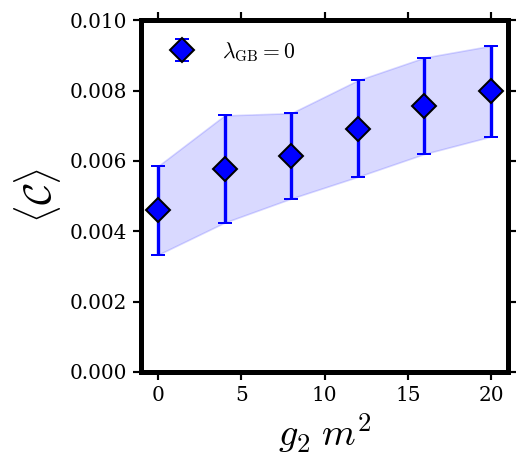

In [168]:
from collections import defaultdict
from scipy.signal import find_peaks


def _peak_stats_last_window(shifted_ln_a, C, dlna, prominence_rel=0.0,
                            min_separation=1):
    """Mean / std / count of local maxima of C(t) in the last `dlna` e-folds.

    Returns (peak_mean, peak_std, n_peaks). If fewer than one interior maximum
    is found, falls back to (max(C_window), 0.0, 0) so the run is still
    plotted with a zero error bar (and is flagged in the printout).

    Parameters
    ----------
    prominence_rel : float
        Minimum peak prominence as a fraction of the window's C-range. Set to
        a small value (e.g. 0.01) to ignore numerical ripples.
    min_separation : int
        Minimum spacing (in samples) between successive peaks.
    """
    sln = np.asarray(shifted_ln_a, dtype=float)
    C   = np.asarray(C,            dtype=float)
    finite = np.isfinite(sln) & np.isfinite(C)
    if not finite.any():
        return np.nan, np.nan, 0
    sln_f = sln[finite]
    C_f   = C[finite]
    lna_max = sln_f.max()
    mask = sln_f >= (lna_max - dlna)
    if not mask.any():
        return np.nan, np.nan, 0
    C_win = C_f[mask]
    if C_win.size < 3:
        return float(C_win.max()), 0.0, 0

    kw = {}
    if min_separation > 1:
        kw["distance"] = int(min_separation)
    if prominence_rel > 0.0:
        rng = float(C_win.max() - C_win.min())
        if rng > 0:
            kw["prominence"] = prominence_rel * rng

    peak_idx, _ = find_peaks(C_win, **kw)
    if peak_idx.size == 0:
        return float(C_win.max()), 0.0, 0
    peaks = C_win[peak_idx]
    return float(np.mean(peaks)), float(np.std(peaks)), int(peaks.size)


colors_lgb  = ["blue", "#f1c40f", "#8e44ad",
               "#e67e22", "#1abc9c", "#34495e", "#e74c3c", "#27ae60", "#2c3e50", "#c0392b"]
markers_lgb = ["D", "s", "D", "^", "v", "<", ">", "P", "X"]

lgb_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4B_MU or beta != P4B_BETA or amp != P4B_AMP or width != P4B_WIDTH:
        continue
    if lgb not in P4B_LGB_SHOW or g2 not in P4B_G2_SHOW:
        continue
    lgb_groups[lgb].append(key)

all_lgbs = sorted(lgb_groups.keys())

fig, ax = plt.subplots(figsize=(4.5,4))

for idx, lgb_val in enumerate(all_lgbs):
    color  = colors_lgb[idx % len(colors_lgb)]
    marker = markers_lgb[idx % len(markers_lgb)]

    points = []
    for key in lgb_groups[lgb_val]:
        d   = all_runs[key]
        sln = d["shifted_ln_a"]
        C   = np.asarray(d["osc"]["C"])

        C_peak_mean, C_peak_std, n_peaks = _peak_stats_last_window(sln, C, P4B_DLNA)
        if not np.isfinite(C_peak_mean):
            continue

        points.append((key[5], C_peak_mean, C_peak_std, n_peaks))

    if not points:
        continue

    points = sorted(points, key=lambda p: p[0])
    x      = np.array([p[0] for p in points])
    y_mean = np.array([p[1] for p in points])
    y_err  = np.array([p[2] for p in points])

    label = rf"$\lambda_{{\rm GB}}={lgb_val:g}$"

    ax.fill_between(x, y_mean - y_err, y_mean + y_err, color=color, alpha=0.15)
    ax.errorbar(x, y_mean, yerr=y_err,
                fmt=marker, color=color,
                markeredgecolor="k", markeredgewidth=1.2,
                capsize=4, capthick=1.2, elinewidth=2, markersize=10,
                label=label)

    print(f"lgb={lgb_val:g}:")
    for g2v, Cm, Ce, n in points:
        if n == 0:
            tag = "  (fallback: 0 peaks, used max of window)"
        elif n == 1:
            tag = "  (1 peak only -> 0 error)"
        else:
            tag = ""
        print(f"   g2={g2v:>6g}  n_peaks={n:3d}   "
              f"C_peak={Cm:.4e} +/- {Ce:.2e}{tag}")

ax.set_xlabel(r"$g_2\;m^2$")
ax.set_ylabel(r"$\langle\mathcal{C}\rangle$")
ax.set_ylim(0, 0.01)
ax.tick_params(which="both", top=True, right=True)
ax.legend(loc="best", frameon=False)
fig.tight_layout()
save_fig(fig, P4B_NAME)
plt.show()

## Panel 4c — Compactness $\mathcal{C}$ vs $\lambda_{\rm GB}$ (peak statistics, last 0.2 e-folds)

Same estimator as Panel 4b, but the x-axis is now $\lambda_{\rm GB}$ and each curve
corresponds to a fixed $g_2$. In the **last $\Delta\ln a = 0.2$ e-folds** of the aligned
`shifted_ln_a` axis, the local maxima of $\mathcal{C}(t)$ are identified, and

$$\langle\mathcal{C}\rangle = \overline{\mathcal{C}_{\rm peak}}, \qquad
  \sigma_{\mathcal{C}} = \mathrm{std}\bigl(\mathcal{C}_{\rm peak}\bigr).$$

The error bar measures cycle-to-cycle scatter of the maximum compactness between successive
breaths, not the full oscillation amplitude.

In [163]:
### --- Panel 4c selection (edit me) ---
P4C_MU       = 0.08
P4C_BETA     = 0
P4C_AMP      = -0.02
P4C_WIDTH    = 3.0

# Which g2 curves to overlay (one curve per value).
P4C_G2_SHOW  = [0]

# Which lambda_GB values appear on the x-axis (only those present in `all_runs` are used).
P4C_LGB_SHOW = [0, 1, 2, 3,4,5,6,7,8]

# Width of the averaging window (last `P4C_DLNA` e-folds of shifted_ln_a).
P4C_DLNA     = 0.2

P4C_NAME     = "compactness_vs_lgb_last02efold"

print(f"g2  to plot: {P4C_G2_SHOW}")
print(f"lgb to plot: {P4C_LGB_SHOW}")
print(f"averaging window: last {P4C_DLNA} e-folds of shifted_ln_a")
print(f"filter:  beta={P4C_BETA}, mu={P4C_MU}, A={P4C_AMP}, R={P4C_WIDTH}")

g2  to plot: [0]
lgb to plot: [0, 1, 2, 3, 4, 5, 6, 7, 8]
averaging window: last 0.2 e-folds of shifted_ln_a
filter:  beta=0, mu=0.08, A=-0.02, R=3.0


g2=0:
   lgb=     0  n_peaks= 45   C_peak=4.5936e-03 +/- 1.26e-03
   lgb=     1  n_peaks= 43   C_peak=4.8181e-03 +/- 1.30e-03
   lgb=     2  n_peaks= 44   C_peak=5.0742e-03 +/- 1.47e-03
   lgb=     3  n_peaks= 40   C_peak=4.8685e-03 +/- 1.35e-03
   lgb=     4  n_peaks= 44   C_peak=4.9361e-03 +/- 1.30e-03
   lgb=     5  n_peaks= 42   C_peak=5.1383e-03 +/- 1.36e-03
   lgb=     8  n_peaks= 41   C_peak=5.5289e-03 +/- 1.40e-03
  saved compactness_vs_lgb_last02efold.pdf and compactness_vs_lgb_last02efold.png


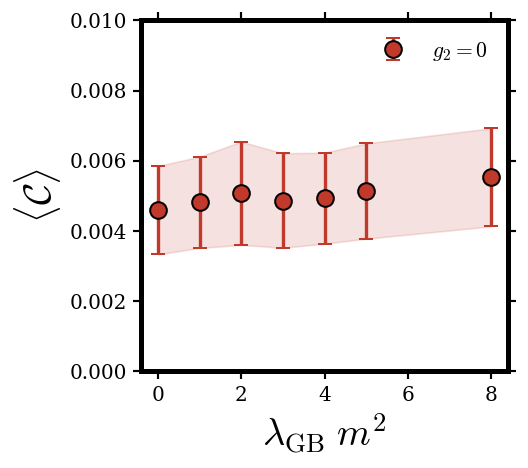

In [170]:
from collections import defaultdict
from scipy.signal import find_peaks

# `_peak_stats_last_window` is defined in Panel 4b; re-define here so this cell
# is self-contained if Panel 4b has not been executed in this session.
try:
    _peak_stats_last_window  # type: ignore[name-defined]
except NameError:
    def _peak_stats_last_window(shifted_ln_a, C, dlna, prominence_rel=0.0,
                                min_separation=1):
        """Mean / std / count of local maxima of C(t) in the last `dlna` e-folds."""
        sln = np.asarray(shifted_ln_a, dtype=float)
        C   = np.asarray(C,            dtype=float)
        finite = np.isfinite(sln) & np.isfinite(C)
        if not finite.any():
            return np.nan, np.nan, 0
        sln_f = sln[finite]
        C_f   = C[finite]
        lna_max = sln_f.max()
        mask = sln_f >= (lna_max - dlna)
        if not mask.any():
            return np.nan, np.nan, 0
        C_win = C_f[mask]
        if C_win.size < 3:
            return float(C_win.max()), 0.0, 0
        kw = {}
        if min_separation > 1:
            kw["distance"] = int(min_separation)
        if prominence_rel > 0.0:
            rng = float(C_win.max() - C_win.min())
            if rng > 0:
                kw["prominence"] = prominence_rel * rng
        peak_idx, _ = find_peaks(C_win, **kw)
        if peak_idx.size == 0:
            return float(C_win.max()), 0.0, 0
        peaks = C_win[peak_idx]
        return float(np.mean(peaks)), float(np.std(peaks)), int(peaks.size)


colors_g2  = [ "#c0392b", "#2980b9", "#f1c40f", "#8e44ad",
              "#e67e22", "#1abc9c", "#34495e", "#e74c3c", "#27ae60","#2c3e50"]
markers_g2 = ["o", "s", "D", "^", "v", "<", ">", "P", "X"]

g2_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4C_MU or beta != P4C_BETA or amp != P4C_AMP or width != P4C_WIDTH:
        continue
    if g2 not in P4C_G2_SHOW or lgb not in P4C_LGB_SHOW:
        continue
    g2_groups[g2].append(key)

all_g2s = sorted(g2_groups.keys())

fig, ax = plt.subplots(figsize=(4.5,4))

for idx, g2_val in enumerate(all_g2s):
    color  = colors_g2[idx % len(colors_g2)]
    marker = markers_g2[idx % len(markers_g2)]

    points = []
    for key in g2_groups[g2_val]:
        d   = all_runs[key]
        sln = d["shifted_ln_a"]
        C   = np.asarray(d["osc"]["C"])

        C_peak_mean, C_peak_std, n_peaks = _peak_stats_last_window(sln, C, P4C_DLNA)
        if not np.isfinite(C_peak_mean):
            continue

        points.append((key[0], C_peak_mean, C_peak_std, n_peaks))

    if not points:
        continue

    points = sorted(points, key=lambda p: p[0])
    x      = np.array([p[0] for p in points])
    y_mean = np.array([p[1] for p in points])
    y_err  = np.array([p[2] for p in points])

    label = rf"$g_2={g2_val:g}$"

    ax.fill_between(x, y_mean - y_err, y_mean + y_err, color=color, alpha=0.15)
    ax.errorbar(x, y_mean, yerr=y_err,
                fmt=marker, color=color,
                markeredgecolor="k", markeredgewidth=1.2,
                capsize=4, capthick=1.2, elinewidth=2, markersize=10,
                label=label)

    print(f"g2={g2_val:g}:")
    for lgbv, Cm, Ce, n in points:
        if n == 0:
            tag = "  (fallback: 0 peaks, used max of window)"
        elif n == 1:
            tag = "  (1 peak only -> 0 error)"
        else:
            tag = ""
        print(f"   lgb={lgbv:>6g}  n_peaks={n:3d}   "
              f"C_peak={Cm:.4e} +/- {Ce:.2e}{tag}")

ax.set_xlabel(r"$\lambda_{\rm GB}\;m^2$")
ax.set_ylabel(r"$\langle\mathcal{C}\rangle$")
ax.set_ylim(0, 0.01)
ax.tick_params(which="both", top=True, right=True)
ax.legend(loc="best", frameon=False)
fig.tight_layout()
save_fig(fig, P4C_NAME)
plt.show()

## Panel 4d — Side-by-side $\mathcal{C}$ vs $\lambda_{\rm GB}$ and $\mathcal{C}$ vs $g_2$

Combines Panels 4c (left, $\mathcal{C}$ vs $\lambda_{\rm GB}$, one curve per $g_2$) and
4b (right, $\mathcal{C}$ vs $g_2$, one curve per $\lambda_{\rm GB}$) in a single 1×2
figure with a shared y-axis. Both panels use the same peak-statistics estimator
(`_peak_stats_last_window`) from Panel 4b and the existing `P4B_*` / `P4C_*` selection
variables, so editing either selection cell automatically updates this panel as well.

  saved compactness_vs_lgb_and_g2.pdf and compactness_vs_lgb_and_g2.png


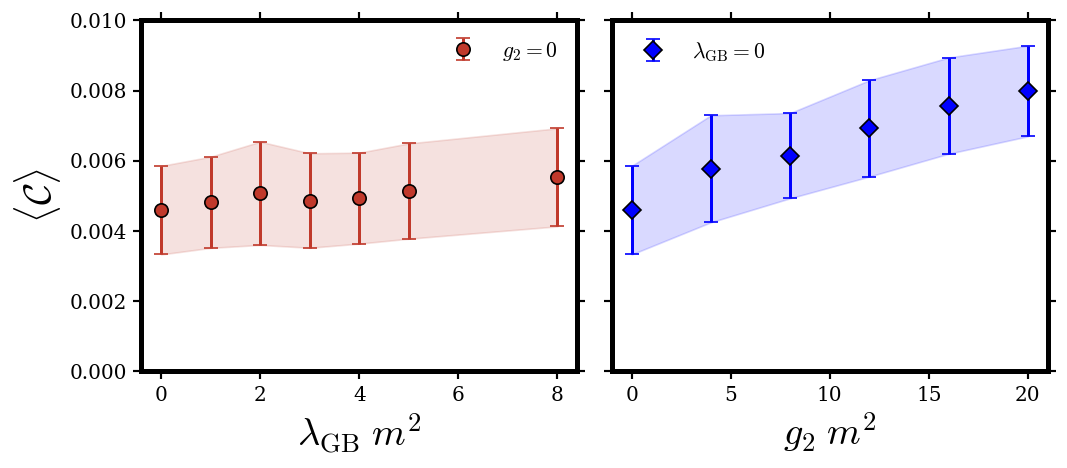

In [173]:
from collections import defaultdict
from scipy.signal import find_peaks

# Reuse `_peak_stats_last_window` from Panel 4b; re-define defensively so this
# cell stands on its own if Panel 4b has not been executed in this session.
try:
    _peak_stats_last_window  # type: ignore[name-defined]
except NameError:
    def _peak_stats_last_window(shifted_ln_a, C, dlna, prominence_rel=0.0,
                                min_separation=1):
        sln = np.asarray(shifted_ln_a, dtype=float)
        C   = np.asarray(C,            dtype=float)
        finite = np.isfinite(sln) & np.isfinite(C)
        if not finite.any():
            return np.nan, np.nan, 0
        sln_f = sln[finite]
        C_f   = C[finite]
        lna_max = sln_f.max()
        mask = sln_f >= (lna_max - dlna)
        if not mask.any():
            return np.nan, np.nan, 0
        C_win = C_f[mask]
        if C_win.size < 3:
            return float(C_win.max()), 0.0, 0
        kw = {}
        if min_separation > 1:
            kw["distance"] = int(min_separation)
        if prominence_rel > 0.0:
            rng = float(C_win.max() - C_win.min())
            if rng > 0:
                kw["prominence"] = prominence_rel * rng
        peak_idx, _ = find_peaks(C_win, **kw)
        if peak_idx.size == 0:
            return float(C_win.max()), 0.0, 0
        peaks = C_win[peak_idx]
        return float(np.mean(peaks)), float(np.std(peaks)), int(peaks.size)


# Same palettes/markers used in Panels 4b and 4c.
_colors_lgb_d  = ["blue", "#f1c40f", "#8e44ad", "#e67e22", "#1abc9c",
                  "#34495e", "#e74c3c", "#27ae60", "#2c3e50", "#c0392b"]
_markers_lgb_d = ["D", "s", "D", "^", "v", "<", ">", "P", "X"]

_colors_g2_d   = ["#c0392b", "#2980b9", "#f1c40f", "#8e44ad", "#e67e22",
                  "#1abc9c", "#34495e", "#e74c3c", "#27ae60", "#2c3e50"]
_markers_g2_d  = ["o", "s", "D", "^", "v", "<", ">", "P", "X"]


def _collect_points(groups, dlna, key_index):
    """For each group, return a sorted list of (x, C_peak_mean, C_peak_std)."""
    out = {}
    for grp_val, keys in groups.items():
        pts = []
        for key in keys:
            d = all_runs[key]
            Cm, Ce, n = _peak_stats_last_window(
                d["shifted_ln_a"], np.asarray(d["osc"]["C"]), dlna)
            if not np.isfinite(Cm):
                continue
            pts.append((key[key_index], Cm, Ce))
        if pts:
            out[grp_val] = sorted(pts, key=lambda p: p[0])
    return out


fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

# ── Left panel: C vs lambda_GB, one curve per g2 (uses Panel 4c selection) ──
g2_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4C_MU or beta != P4C_BETA or amp != P4C_AMP or width != P4C_WIDTH:
        continue
    if g2 not in P4C_G2_SHOW or lgb not in P4C_LGB_SHOW:
        continue
    g2_groups[g2].append(key)

g2_points = _collect_points(g2_groups, P4C_DLNA, key_index=0)
for idx, g2_val in enumerate(sorted(g2_points.keys())):
    pts    = g2_points[g2_val]
    color  = _colors_g2_d[idx % len(_colors_g2_d)]
    marker = _markers_g2_d[idx % len(_markers_g2_d)]
    x  = np.array([p[0] for p in pts])
    y  = np.array([p[1] for p in pts])
    ye = np.array([p[2] for p in pts])
    ax_l.fill_between(x, y - ye, y + ye, color=color, alpha=0.15)
    ax_l.errorbar(x, y, yerr=ye, fmt=marker, color=color,
                  markeredgecolor="k", markeredgewidth=1.0,
                  capsize=4, capthick=1.0, elinewidth=1.8, markersize=8,
                  label=rf"$g_2={g2_val:g}$")

ax_l.set_xlabel(r"$\lambda_{\rm GB}\;m^2$")
ax_l.set_ylabel(r"$\langle\mathcal{C}\rangle$")
ax_l.set_ylim(0, 0.01)
ax_l.tick_params(which="both", top=True, right=True)
ax_l.legend(loc="best", frameon=False)

# ── Right panel: C vs g2, one curve per lambda_GB (uses Panel 4b selection) ──
lgb_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4B_MU or beta != P4B_BETA or amp != P4B_AMP or width != P4B_WIDTH:
        continue
    if lgb not in P4B_LGB_SHOW or g2 not in P4B_G2_SHOW:
        continue
    lgb_groups[lgb].append(key)

lgb_points = _collect_points(lgb_groups, P4B_DLNA, key_index=5)
for idx, lgb_val in enumerate(sorted(lgb_points.keys())):
    pts    = lgb_points[lgb_val]
    color  = _colors_lgb_d[idx % len(_colors_lgb_d)]
    marker = _markers_lgb_d[idx % len(_markers_lgb_d)]
    x  = np.array([p[0] for p in pts])
    y  = np.array([p[1] for p in pts])
    ye = np.array([p[2] for p in pts])
    ax_r.fill_between(x, y - ye, y + ye, color=color, alpha=0.15)
    ax_r.errorbar(x, y, yerr=ye, fmt=marker, color=color,
                  markeredgecolor="k", markeredgewidth=1.0,
                  capsize=4, capthick=1.0, elinewidth=1.8, markersize=8,
                  label=rf"$\lambda_{{\rm GB}}={lgb_val:g}$")

ax_r.set_xlabel(r"$g_2\;m^2$")
ax_r.tick_params(which="both", top=True, right=True)
ax_r.legend(loc="best", frameon=False)

fig.tight_layout()
save_fig(fig, "compactness_vs_lgb_and_g2")
plt.show()

## Panel 4a — Max compactness heatmap over $(\lambda_{\rm GB},\, g_2)$

2D heatmap (discrete blocks) of the maximum compactness $\max_{\ln(a)>2}\mathcal{C}$ for each
available run with $\beta=0$ at the chosen $(\mu, A, R)$. The plot is filled from the runs already
loaded into `all_runs` (so only 1/24 resolution since `FILTER_DR=1/24`); missing cells are shown in
grey and listed under the plot as a TODO list of runs you may want to compute.

Both axes default to integer step (`0, 1, 2, ..., 20`). Change `P4A_STEP_LGB` / `P4A_STEP_G2` to
`2`, `5`, etc. to thin the grid.

In [129]:
### --- Panel 4a selection (edit me) ---
P4A_MU     = 0.08
P4A_BETA   = 0
P4A_AMP    = -0.02
P4A_WIDTH  = 3.0

P4A_LGB_MIN, P4A_LGB_MAX = 0, 20
P4A_G2_MIN,  P4A_G2_MAX  = 0, 22
P4A_STEP_LGB = 4    # 1, 2, 5, ...
P4A_STEP_G2  = 4     # 1, 2, 5, ...

P4A_LNA_MIN  = 2.0   # max compactness measured on shifted_ln_a > this
P4A_CMAP     = "Blues"
P4A_VMIN     = None  # log-norm lower bound; None = auto from data
P4A_VMAX     = None  # log-norm upper bound; None = auto from data
P4A_NLEVELS  = 8     # number of discrete colour blocks (cells + colourbar)

P4A_NAME = "compactness_heatmap_lgb_g2"

P4A_LGB_VALUES = np.arange(P4A_LGB_MIN, P4A_LGB_MAX + P4A_STEP_LGB, P4A_STEP_LGB)
P4A_G2_VALUES  = np.arange(P4A_G2_MIN,  P4A_G2_MAX  + P4A_STEP_G2,  P4A_STEP_G2)

print(f"lgb grid ({len(P4A_LGB_VALUES)} pts): {list(P4A_LGB_VALUES)}")
print(f"g2  grid ({len(P4A_G2_VALUES)} pts): {list(P4A_G2_VALUES)}")
print(f"filter:  beta={P4A_BETA}, mu={P4A_MU}, A={P4A_AMP}, R={P4A_WIDTH}, dr=1/24 (from loader)")

lgb grid (6 pts): [np.int64(0), np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20)]
g2  grid (7 pts): [np.int64(0), np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20), np.int64(24)]
filter:  beta=0, mu=0.08, A=-0.02, R=3.0, dr=1/24 (from loader)


Filled 18 / 42 cells.
  saved compactness_heatmap_lgb_g2.pdf and compactness_heatmap_lgb_g2.png


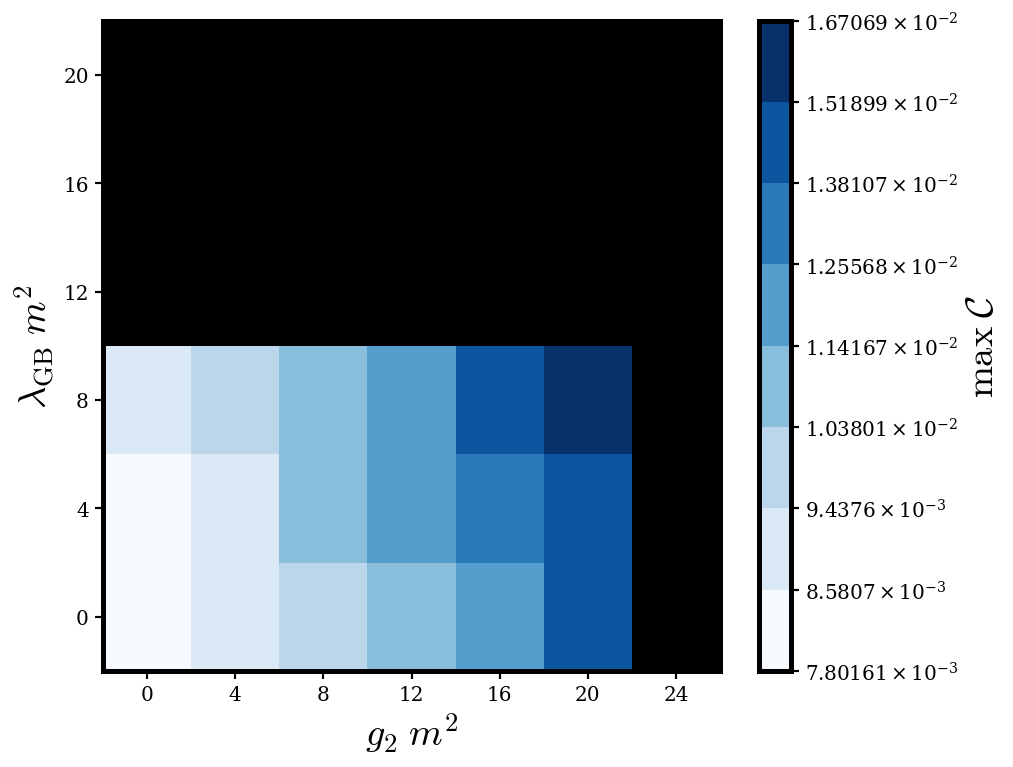


--- Suggested runs to compute (1/24 resolution) ---

Missing entirely (7 runs):
  lgb=  0: g2 = [24.0]
  lgb=  4: g2 = [24.0]
  lgb=  8: g2 = [24.0]
  lgb= 12: g2 = [24.0]
  lgb= 16: g2 = [24.0]
  lgb= 20: g2 = [12.0, 24.0]

Run exists but has no data for shifted_ln_a > 2.0 (17 runs):
  lgb= 12, g2=0
  lgb= 12, g2=4
  lgb= 12, g2=8
  lgb= 12, g2=12
  lgb= 12, g2=16
  lgb= 12, g2=20
  lgb= 16, g2=0
  lgb= 16, g2=4
  lgb= 16, g2=8
  lgb= 16, g2=12
  lgb= 16, g2=16
  lgb= 16, g2=20
  lgb= 20, g2=0
  lgb= 20, g2=4
  lgb= 20, g2=8
  lgb= 20, g2=16
  lgb= 20, g2=20


In [130]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import LogFormatterSciNotation
from collections import defaultdict

ny, nx = len(P4A_LGB_VALUES), len(P4A_G2_VALUES)
Z = np.full((ny, nx), np.nan)

missing_no_run     = []
missing_no_late_C  = []
for i, lgb in enumerate(P4A_LGB_VALUES):
    for j, g2 in enumerate(P4A_G2_VALUES):
        key = (float(lgb), float(P4A_MU), float(P4A_BETA),
               float(P4A_AMP), float(P4A_WIDTH), float(g2))
        if key not in all_runs:
            missing_no_run.append((int(lgb), float(g2)))
            continue
        d   = all_runs[key]
        sln = d["shifted_ln_a"]
        C   = np.asarray(d["osc"]["C"])
        m   = sln > P4A_LNA_MIN
        if m.any() and np.isfinite(C[m]).any():
            Z[i, j] = float(np.nanmax(C[m]))
        else:
            missing_no_late_C.append((int(lgb), float(g2)))

filled = int(np.isfinite(Z).sum())
print(f"Filled {filled} / {ny*nx} cells.")

# Cell edges (half-step on each side of every grid point)
def _edges(vals, step):
    v = np.asarray(vals, dtype=float)
    return np.concatenate([v - step / 2.0, v[-1:] + step / 2.0])
g2_edges  = _edges(P4A_G2_VALUES,  P4A_STEP_G2)
lgb_edges = _edges(P4A_LGB_VALUES, P4A_STEP_LGB)

finite = Z[np.isfinite(Z) & (Z > 0)]
vmin = P4A_VMIN if P4A_VMIN is not None else (float(finite.min()) if finite.size else 1e-4)
vmax = P4A_VMAX if P4A_VMAX is not None else (float(finite.max()) if finite.size else 1e-1)

# Log-spaced discrete levels -> discrete cells AND discrete colourbar blocks.
levels = np.logspace(np.log10(vmin), np.log10(vmax), P4A_NLEVELS + 1)
cmap   = plt.get_cmap(P4A_CMAP, P4A_NLEVELS).copy()
cmap.set_bad("black")
norm   = BoundaryNorm(boundaries=levels, ncolors=P4A_NLEVELS)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
pc = ax.pcolormesh(g2_edges, lgb_edges, Z, shading="flat",
                   norm=norm, cmap=cmap)
cbar = fig.colorbar(pc, ax=ax, ticks=levels, spacing="uniform",
                    format=LogFormatterSciNotation())
cbar.set_label(r"$\max\;\mathcal{C}$")

ax.set_xlabel(r"$g_2\;m^2$")
ax.set_ylabel(r"$\lambda_{\rm GB}\;m^2$")
#ax.set_title(rf"Max compactness vs $(\lambda_{{\rm GB}},\, g_2)$; "rf"$\beta={P4A_BETA},\ \mu={P4A_MU},\ A={P4A_AMP},\ R={P4A_WIDTH}$")
ax.set_xticks(P4A_G2_VALUES)
ax.set_yticks(P4A_LGB_VALUES)
ax.set_aspect("auto")
ax.grid(False)

fig.tight_layout()
save_fig(fig, P4A_NAME)
plt.show()

# Suggested runs: missing (lgb, g2) cells
if missing_no_run or missing_no_late_C:
    print("\n--- Suggested runs to compute (1/24 resolution) ---")
    if missing_no_run:
        by_lgb = defaultdict(list)
        for lgb, g2 in missing_no_run:
            by_lgb[lgb].append(g2)
        print(f"\nMissing entirely ({len(missing_no_run)} runs):")
        for lgb in sorted(by_lgb):
            print(f"  lgb={lgb:>3d}: g2 = {by_lgb[lgb]}")
    if missing_no_late_C:
        print(f"\nRun exists but has no data for shifted_ln_a > {P4A_LNA_MIN} ({len(missing_no_late_C)} runs):")
        for lgb, g2 in sorted(missing_no_late_C):
            print(f"  lgb={lgb:>3d}, g2={g2:g}")
else:
    print("\nAll requested cells are filled.")

## Panel 4 — Compactness, weak-coupling and $g_2$ hyperbolicity

Three stacked panels sharing the x-axis (aligned $\ln(a)$, fixed to $[2,\,3.5]$):
1. Compactness $\mathcal{C}$
2. Weak-coupling condition $\max_r \sqrt{|\lambda'|}\,L^{-1}$ (and $\sqrt{|g_2|}\,\tilde L^{-1}$ dashed where $g_2 \neq 0$)
3. $g_2$ hyperbolicity: $\min_r$ of $\det(g^{\rm eff}_{\mu\nu})/\det(g_{\mu\nu})$

GR (`lgb=0, g2=0`) is drawn as a thick black line. EFT diagnostics are computed (and cached
on disk) only for the selected runs. Set `FORCE_EFT_RECOMPUTE = True` to overwrite the
cached `eft_diagnostics.npz`.

In [174]:
### --- Panel 4 selection (edit me) ---
PLOT4_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0,20],
)
"""
PLOT4_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0, 10, 20],
)
"""
PLOT4_NAME = "rho_C_WCC_hyp"

R_WCC_MAX           = 100.0   # only consider r in (0, R_WCC_MAX] for WCC / hyperbolicity maxima
FORCE_EFT_RECOMPUTE = False   # True = ignore any cached eft_diagnostics.npz and recompute

print(f"{len(PLOT4_KEYS)} run(s) selected for Panel 4:")
for k in PLOT4_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"], " g2=", k[5])

# Compute / load EFT diagnostics only for the selected runs
for k in PLOT4_KEYS:
    d = all_runs[k]
    if "eft" in d and not FORCE_EFT_RECOMPUTE:
        continue
    run_dir  = d["run_dir"]
    eft_path = os.path.join(run_dir, "eft_diagnostics.npz")
    if os.path.exists(eft_path) and not FORCE_EFT_RECOMPUTE:
        d["eft"] = dict(np.load(eft_path, allow_pickle=True))
        print(f"  [EFT] loaded cache for {d['tag']}")
    else:
        sol_i    = np.load(os.path.join(run_dir, "solution.npy"))
        matter_i = ScalarMatter(scalar_mu, d["mu"])
        sv_i     = StateVector(matter_i)
        spacing_i = CubicSpacing(**CubicSpacing.get_parameters(
            d["run_r_max"], d["run_min_dr"], d["run_max_dr"]))
        grid_i   = Grid(spacing_i, sv_i)
        bg_i     = FlatSphericalBackground(grid_i.r)
        lgb_k, mu_k, beta_k, amp_k, width_k, g2_k = k
        params = (lgb_k, a_mg, b_mg, chi0, d["coupling"], g2_k)
        eft = get_eft_diagnostic(
            sol_i, d["t"], grid_i, bg_i,
            ScalarMatter(scalar_mu, d["mu"]),
            params,
        )
        np.savez(eft_path, **eft)
        d["eft"] = eft
        del sol_i
        verb = "recomputed" if FORCE_EFT_RECOMPUTE else "computed"
        print(f"  [EFT] {verb} & cached for {d['tag']}")

2 run(s) selected for Panel 4:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic  g2= 0.0
  (0.0, 0.08, 0.0, -0.02, 3.0, 20.0)  coupling= quadratic  g2= 20.0
  [EFT] loaded cache for lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  [EFT] loaded cache for lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g220


  saved rho_C_WCC_hyp.pdf and rho_C_WCC_hyp.png


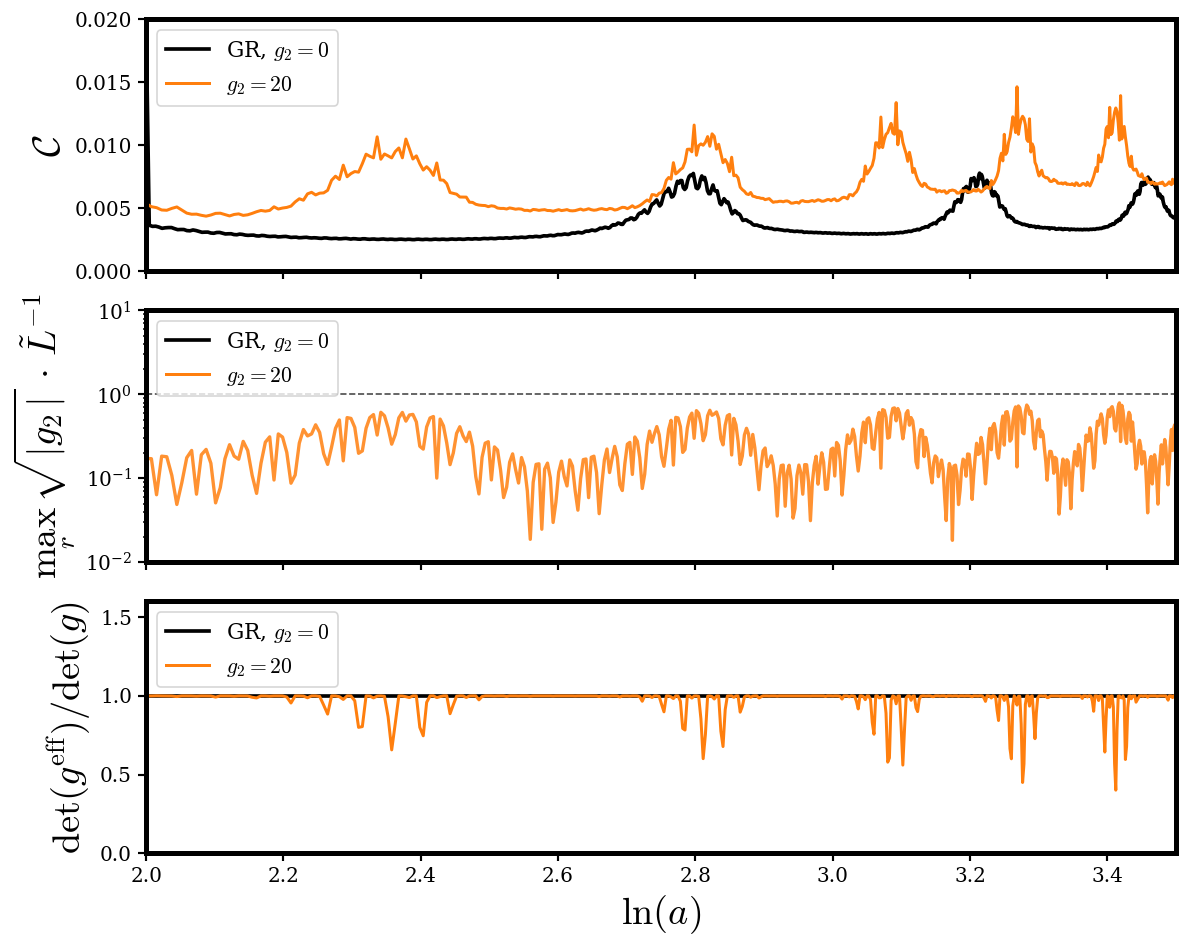

In [182]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
cmap = plt.cm.tab10

if len(PLOT4_KEYS) == 0:
    print("No keys selected for Panel 4.")
else:
    first = all_runs[PLOT4_KEYS[0]]
    r0    = first["eft"]["r"] if ("eft" in first) else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX) if r0 is not None else None

    for i, key in enumerate(PLOT4_KEYS):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)
        lgb, mu, beta, amp, width, g2 = key

        is_gr = (lgb == 0.0 and g2 == 0.0)
        beta_str = rf", \beta={int(beta)}" if (beta is not None and beta != 250) else ""
        g2_str   = rf"g_2={g2:g}"
        if is_gr:
            label = rf"GR, ${g2_str}$"
        else:
            label = rf"${g2_str}$"
        color = "k" if is_gr else cmap(i % 10)
        lw    = 2.2 if is_gr else 1.8

        x = run["shifted_ln_a"]

        # Panel 0: compactness
        axes[0].plot(x, osc["C"], color=color, lw=lw, label=label)

        # Panel 1: weak-coupling conditions (need eft data)
        if eft is not None and r_mask is not None:
            wc_lam = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
            axes[1].plot(x, wc_lam, color=color, lw=lw, label=label)
            if g2 != 0 and "wc_g2_bare" in eft:
                wc_g2 = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)
                axes[1].plot(x, wc_g2, color=color, lw=2, ls="-", alpha=0.85)

        # Panel 2: g2 hyperbolicity
        if eft is not None and "disc_g2" in eft and r_mask is not None:
            disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
            axes[2].plot(x, disc_g2_min, color=color, lw=lw, label=label)

    axes[0].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[0].set_ylabel(r"$\mathcal{C}$")
    #axes[0].set_title(r"Compactness $\mathcal{C}$")
    #axes[0].grid(False, alpha=0.3)
    axes[0].set_ylim(0, 0.02)

    axes[1].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.7)
    axes[1].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    #axes[1].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,\cdot\, \tilde L^{-1}$")
    axes[1].set_ylabel(r"$\max_r\,\sqrt{|g_2|}\,\cdot\, \tilde L^{-1}$")


    #axes[1].set_title(r"Weak-coupling condition") #(GB length scale $L^{-1}$; $g_2$ length scale $\tilde L^{-1}$, dashed)")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-2,1e1)
    #axes[1].grid(False, alpha=0.3)

    axes[2].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[2].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[2].set_ylabel(r"$\det(g^{\rm eff})/\det(g)$")
    #axes[2].set_title(r"$g_2$ hyperbolicity") # (min over $r$)")
    axes[2].set_ylim(0,1.6)
    #axes[2].grid(False, alpha=0.3)

    axes[2].set_xlabel(r"$\ln(a)$")
    # shared x across all three rows via sharex=True
    axes[0].set_xlim(2, 3.5)

    axes[0].legend(fontsize=13, ncol=1, loc="upper left")
    axes[1].legend(fontsize=13, ncol=1, loc="upper left")
    axes[2].legend(fontsize=13, ncol=1, loc="upper left")

    fig.tight_layout()
    save_fig(fig, PLOT4_NAME)
    plt.show()

## Panel 6 — GW spectrum benchmark (Antusch-Cefala-Orani 2017, Fig. 2)

Reproduces the paper's Fig. 2 ($w=0$, single cosine oscillon source, integrated to $a_f=3$) using the
`Omega_GW` semi-analytic model from `bssn.GWSignal`. One curve per asymmetry $\Delta$ in the
list below; the spectrum is plotted vs $k_{\rm phys}/\omega_{\rm osc}$ in log-log space.

In [16]:
### --- Panel 6 selection (edit me) ---
from bssn.GWSignal import Omega_GW

# Paper defaults (Antusch-Cefala-Orani 2017, eqs. 4.6-4.7), in units m_Pl = 1
P6_A_PAPER     = 0.05
P6_OMEGA_PAPER = 1.0
P6_R_PAPER     = 1.0
P6_H0_PAPER    = 0.002
P6_V_PAPER     = (100.0 * P6_R_PAPER) ** 3
P6_N_PAPER     = 1
P6_W_PAPER     = 0.0          # matter dominated (paper Fig. 2)
P6_A_F_TARGET  = 3.0          # paper integrates Fig. 2 to a_f = 3

P6_N_ANGLES = 30              # paper uses ~30
P6_N_TAU    = 5000            # raise to 10000 for better low-k resolution
P6_SEED     = 42
P6_NK       = 120             # number of comoving k-grid points

# Which asymmetry values to plot (one curve each)
P6_DELTAS = [0.4]
P6_COLORS = ['C3']            # one entry per delta in P6_DELTAS

P6_NAME = "GW_spectrum_benchmark"

# Invert eq. 4.13 to find t_end such that a(t_end) = A_F_TARGET (matter dom.)
#   a(t) = (9/4)^{1/3} * (2/3 + H0 t)^{2/3}
_pref6 = (9.0 / 4.0) ** (1.0 / 3.0)
P6_T_END = ((P6_A_F_TARGET / _pref6) ** 1.5 - 2.0 / 3.0) / P6_H0_PAPER

# Comoving k-grid covers k_phys/omega_osc in [0.4, 3.0]; default in Omega_GW
# would cut off the peak at k_phys/omega_osc ~ 2.
P6_K_GRID = np.logspace(
    np.log10(0.4 * P6_OMEGA_PAPER * P6_A_F_TARGET),
    np.log10(3.0 * P6_OMEGA_PAPER * P6_A_F_TARGET),
    P6_NK,
)

print(f"Panel 6: {len(P6_DELTAS)} spectrum/spectra; t_end = {P6_T_END:.2e} (a_f target = {P6_A_F_TARGET})")
assert len(P6_COLORS) >= len(P6_DELTAS), "need at least one colour per Delta"

Panel 6: 1 spectrum/spectra; t_end = 1.40e+03 (a_f target = 3.0)


  saved GW_spectrum_benchmark.pdf and GW_spectrum_benchmark.png


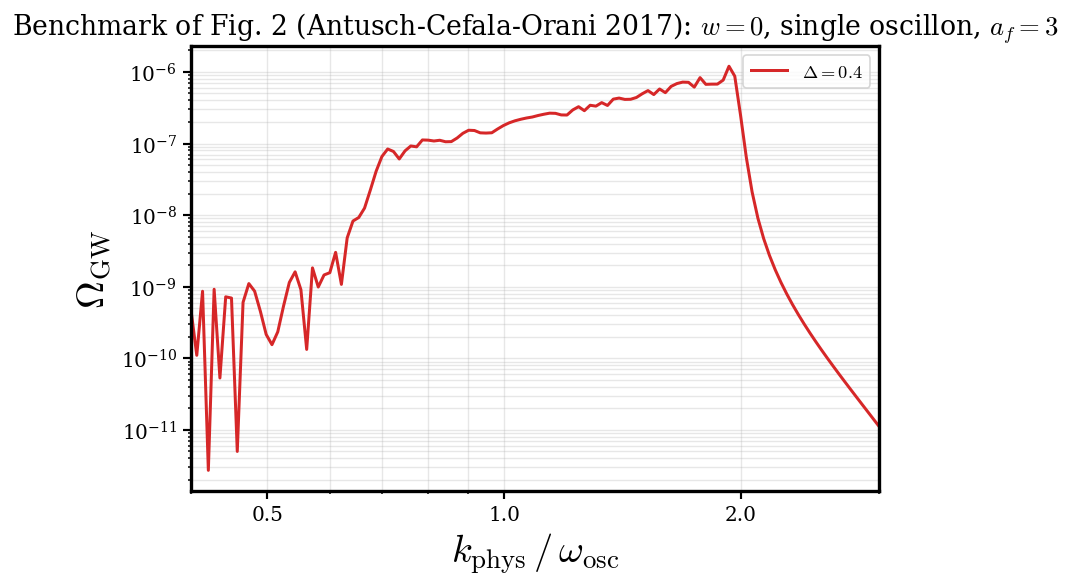

In [17]:
from matplotlib.ticker import ScalarFormatter, FixedLocator

p6_results = {}
fig, ax = plt.subplots(figsize=(7, 5))

for Delta_p, color in zip(P6_DELTAS, P6_COLORS):
    res = Omega_GW(
        A=P6_A_PAPER, R=P6_R_PAPER,
        omega_source=P6_OMEGA_PAPER, H0=P6_H0_PAPER,
        w=P6_W_PAPER, Delta=Delta_p, N=P6_N_PAPER, V=P6_V_PAPER,
        n_angles=P6_N_ANGLES, n_tau=P6_N_TAU,
        k_grid=P6_K_GRID,
        tau_window=(0.0, P6_T_END),
        seed=P6_SEED,
        harmonics='cosine',        # paper uses single cosine source (eq. 4.1)
    )
    p6_results[Delta_p] = res
    ax.loglog(res['k_phys'] / P6_OMEGA_PAPER, res['Omega_GW'],
              color=color, lw=1.8, label=fr"$\Delta = {Delta_p}$")

ax.set_xlabel(r"$k_{\rm phys}\,/\,\omega_{\rm osc}$")
ax.set_ylabel(r"$\Omega_{\rm GW}$")
ax.set_title(r"Benchmark of Fig. 2 (Antusch-Cefala-Orani 2017): $w=0$, single oscillon, $a_f=3$")
ax.set_xlim(0.4, 3.0)
ax.xaxis.set_major_locator(FixedLocator([0.5, 1.0, 2.0]))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11, loc='best', frameon=True)

fig.tight_layout()
save_fig(fig, P6_NAME)
plt.show()